# G10 FX Strategy — Full Analysis Notebook

**Covers:** Data Acquisition · Currency Excess Returns · Carry · Momentum · Dollar · In-sample Portfolios · Out-of-sample CMVE Portfolios

**Currencies:** AUD, CAD, EUR, GBP, JPY, NZD (vs USD)

**Evaluation sample:** January 1995 – December 2024 (360 observations)  
**Full return sample:** January 1991 – December 2024  
**Holdout sample:** January 1991 – December 1994 (used to initialize OOS estimators)

All tables and figures match those described in `Project_2026.pdf`.

---

────────────────────────────────────────────────────────────────────────

## # Part 1 — Data Acquisition & Setup

────────────────────────────────────────────────────────────────────────

## 0. Imports and constants

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

PROJECT_DIR   = Path('..').resolve()
RAW_DIR       = PROJECT_DIR / 'data' / 'raw'
FRED_DIR      = RAW_DIR / 'fred'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

import wrds

# -----------------------------
# Datastream FX series codes (given in the project pdf)
# -----------------------------
DS_CODE_MAP = {
    2427: ("AUD", "spot"), 2601: ("AUD", "fwd"),
    2429: ("CAD", "spot"), 2616: ("CAD", "fwd"),
    2561: ("EUR", "spot"), 2562: ("EUR", "fwd"),
    2428: ("GBP", "spot"), 2539: ("GBP", "fwd"),
    2538: ("JPY", "spot"), 2544: ("JPY", "fwd"),
    2441: ("NZD", "spot"), 2676: ("NZD", "fwd"),
}

codes_sql = ",".join(str(c) for c in DS_CODE_MAP.keys())

# Datastream quotes some currencies as 'USD per FCU' and others as 'FCU per USD'.
# We want all rates as USD per FCU. Rule of thumb (verify with the magnitude-check cell below):
#   AUD, EUR, GBP, NZD  -> already USD per FCU
#   CAD, JPY            -> FCU per USD, need to invert

INVERT_PER_CODE = {
    2427: True,   2601: False,   # AUD spot=FCU/USD, fwd=USD/FCU
    2429: True,   2616: True,    # CAD both FCU/USD
    2561: False,  2562: False,   # EUR both USD/FCU
    2428: True,   2539: False,   # GBP spot=FCU/USD, fwd=USD/FCU
    2538: True,   2544: True,    # JPY both FCU/USD
    2441: True,   2676: False,   # NZD spot=FCU/USD, fwd=USD/FCU
}

# Path where the raw FX rates from WRDS will be cached locally (avoids re-querying)
#FX_CACHE = RAW_DIR / 'fx_rates_raw.csv'

*Open a WRDS connection and inspect the `tr_ds_equities.ds2fxrate` schema to confirm column layout before pulling data.*

In [114]:

db = wrds.Connection(wrds_username='your_wrds_username')
schema_info = db.raw_sql("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema='tr_ds_equities'
      AND table_name='ds2fxrate'
    ORDER BY ordinal_position
""")

schema_info

Loading library list...
Done


,column_name
0,exrateintcode
1,exratedate
2,midrate
3,bidrate
4,offerrate
5,licflag


*Sanity-check the forward `exrateintcode` values for AUD/GBP/NZD by querying their median rates — Datastream sometimes mislabels series, so we verify magnitudes look like real exchange rates.*

In [ ]:
# --- Discover the real 1-month forward exrateintcode values for AUD/GBP/NZD ----
# Magnitude diagnostics revealed that for AUD/GBP/NZD the two codes we used are
# the SAME spot quoted in opposite directions (spot * "fwd" ~= 1), not spot+fwd.
# Query the Datastream meta table tr_ds_equities.ds2fxcode to pick the right
# forward codes. We first inspect available columns because WRDS naming varies.

db = wrds.Connection(wrds_username='your_wrds_username')
try:
    # 1) Inspect columns on ds2fxcode so we only SELECT columns that actually exist
    cols_df = db.raw_sql("""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = 'tr_ds_equities'
          AND table_name   = 'ds2fxcode'
        ORDER BY ordinal_position
    """)
    available = [c.lower() for c in cols_df['column_name']]
    print('Columns in tr_ds_equities.ds2fxcode:', available)

    # 2) Build the SELECT from the intersection of what we want and what exists
    # We only need the 3 columns below to identify the correct codes
    
    meta_sql = f"""
        SELECT exrateintcode, fromcurrcode, tocurrcode 
        FROM tr_ds_equities.ds2fxcode
        WHERE (fromcurrcode IN ('AUD','GBP','NZD') AND tocurrcode = 'USD')
           OR (fromcurrcode = 'USD' AND tocurrcode IN ('AUD','GBP','NZD'))
        ORDER BY fromcurrcode, tocurrcode, exrateintcode
    """
    meta = db.raw_sql(meta_sql) 
finally:
    db.close()

print(f'\nFound {len(meta)} meta rows for AUD/GBP/NZD pairs.\n')
with pd.option_context('display.max_rows', None,
                       'display.max_colwidth', None,
                       'display.width', 200):
    print(meta.to_string(index=False)) 

Loading library list...
Done
Columns in tr_ds_equities.ds2fxcode: ['exrateintcode', 'exratecode', 'fromcurrcode', 'tocurrcode', 'sourcecode', 'ratetypecode', 'exratedesc']

Found 103 meta rows for AUD/GBP/NZD pairs.

 exrateintcode fromcurrcode tocurrcode
  2,427.000000          AUD        USD
  2,428.000000          GBP        USD
  2,441.000000          NZD        USD
  2,594.000000          USD        AUD
  2,601.000000          USD        AUD
  2,602.000000          USD        AUD
  2,603.000000          USD        AUD
  2,604.000000          USD        AUD
  2,605.000000          USD        AUD
  2,606.000000          USD        AUD
  2,607.000000          USD        AUD
  2,608.000000          USD        AUD
  2,609.000000          USD        AUD
  2,610.000000          USD        AUD
  2,990.000000          USD        AUD
  2,994.000000          USD        AUD
  2,998.000000          USD        AUD
  3,000.000000          USD        AUD
  3,003.000000          USD        AUD
  3

## 1. Pull FX rates from WRDS Datastream

Uses the `wrds` Python package. On first run you will be prompted for your WRDS username/password; afterwards credentials are cached in `~/.pgpass` so subsequent runs connect silently.

The query hits `tr_ds_equities.ds2fxrate`, which stores both spot and 1-month forward mid quotes for the six currencies we need. We save the daily panel to `data/raw/fx_rates_raw.csv` so later runs skip the WRDS call.

In [116]:
# Pull the raw FX rates from WRDS and load into a DataFrame
db = wrds.Connection(wrds_username='your_wrds_username')

fx_raw = db.raw_sql(f"""  
    SELECT exrateintcode,
           exratedate AS marketdate,
           midrate
    FROM tr_ds_equities.ds2fxrate
    WHERE exrateintcode IN ({codes_sql})
      AND exratedate BETWEEN '1990-12-01' AND '2024-12-31'
    ORDER BY exrateintcode, exratedate
""", date_cols=["marketdate"]) 

db.close() # close the connection to WRDS, we don't need it anymore


# Label series (currency, spot/fwd)

map_df = (
    pd.DataFrame.from_dict(DS_CODE_MAP, orient="index", columns=["currency", "type"])     # create DataFrame from the code map
      .reset_index() 
      .rename(columns={"index": "exrateintcode"}) # rename index to match the code column in fx_raw
)

fx = fx_raw.merge(map_df, on="exrateintcode", how="left") # full dataframe with all columns including currency and type


# Convert to USD per FCU
# (invert CAD, JPY)


#fx["invert"] = fx["currency"].map(INVERT_TO_USD_PER_FCU).fillna(False) # create a boolean column 'invert' based on the currency
#fx.loc[fx["invert"], "midrate"] = 1.0 / fx.loc[fx["invert"], "midrate"] # invert the midrate for rows where 'invert' is True
#fx = fx.drop(columns=["invert"]) # drop the helper column
# fx midrate is now in USD per FCU for all rows

# Take last daily observation in each month
fx["month"] = fx["marketdate"].dt.to_period("M").dt.to_timestamp("M") # create a 'month' column by converting marketdate to month-end timestamp

fx_m = (
    fx.sort_values(["currency", "type", "marketdate"]) 
      .groupby(["currency", "type", "month"], as_index=False)
      .last()   # take the last observation in each month for each currency and type to have one row per month
)


fx_wide = fx_m.pivot_table(  # pivot the data to have one row per month and columns for each currency-type combination
    index="month",
    columns=["currency", "type"],
    values="midrate"
)

for code, invert in INVERT_PER_CODE.items():
    currency, typ = DS_CODE_MAP[code]
    if invert:
        fx_wide[(currency, typ)] = 1.0 / fx_wide[(currency, typ)]

fx_wide.columns = fx_wide.columns.map(lambda x: f"{x[0]}_{x[1]}") # flatten the multi-index columns to single level with names like 'AUD_spot', 'AUD_fwd', etc.
fx_wide = fx_wide.sort_index() # ensure the data is sorted by month

fx_wide.head() 

Loading library list...
Done


,AUD_fwd,AUD_spot,CAD_fwd,CAD_spot,EUR_fwd,EUR_spot,GBP_fwd,GBP_spot,JPY_fwd,JPY_spot,NZD_fwd,NZD_spot
month,,,,,,,,,,,,
1990-12-31,0.769500,0.772500,0.859365,0.862069,1.363799,1.367000,1.922250,1.930129,0.007369,0.007372,0.586050,0.587993
1991-01-31,0.779600,0.783270,0.857101,0.860364,1.389999,1.393200,1.955299,1.967343,0.007613,0.007619,0.597050,0.599485
1991-02-28,0.783250,0.785484,0.867491,0.869565,1.342650,1.345650,1.902000,1.910585,0.007507,0.007517,0.597400,0.599485
1991-03-31,0.769400,0.773515,0.860585,0.862999,1.208650,1.211900,1.738250,1.738526,0.007096,0.007106,0.584600,0.586201
1991-04-30,0.779275,0.781984,0.864828,0.867303,1.194900,1.198549,1.725550,1.731002,0.007335,0.007349,0.587500,0.588998


### 1a. Quick magnitude check

Look at the median raw rate per series. Rates around 0.5–2.0 are typically USD per FCU (AUD, EUR, GBP, NZD). Rates well above 1 (e.g. JPY ~110, CAD ~1.3) are FCU per USD and need inverting. This is your chance to adjust `INVERT_TO_USD_PER_FCU` if the defaults don't match your data.

In [117]:
mag = (fx_raw.groupby('exrateintcode')['midrate']
               .median().rename('median_rate').to_frame())
mag['iso']  = mag.index.map(lambda c: DS_CODE_MAP[c][0])
mag['type'] = mag.index.map(lambda c: DS_CODE_MAP[c][1])
mag

,median_rate,iso,type
exrateintcode,,,
"2,427.000000",1.350200,AUD,spot
"2,428.000000",0.640800,GBP,spot
"2,429.000000",1.304199,CAD,spot
"2,441.000000",1.518224,NZD,spot
"2,538.000000",110.837505,JPY,spot
"2,539.000000",1.559725,GBP,fwd
"2,544.000000",110.630500,JPY,fwd
"2,561.000000",1.185450,EUR,spot
"2,562.000000",1.185505,EUR,fwd


## 2. Load FRED short-term interest rates

Expect one CSV per series in `data/raw/fred/`. For the EUR area, we splice Germany (before Jan 1999) with the Euro Area series (from Jan 1999).

*(If you'd rather pull FRED programmatically, replace this section with `pandas_datareader` or `fredapi` calls — the downstream code doesn't care.)*

> **Dependencies.** This notebook requires `pandas`, `pandas-datareader`, `wrds`, `numpy`, `matplotlib`, `scipy`, `statsmodels` and `pyarrow`. Install once with:  
> ```bash
> pip install pandas pandas-datareader wrds numpy matplotlib scipy statsmodels pyarrow
> ```

In [118]:
import pandas as pd
from pandas_datareader.data import DataReader

start, end = "1990-12-01", "2024-12-31"

# Put your FRED series IDs here
SERIES = {
    "USD": "IRSTCI01USM156N",
    "AUD": "IRSTCI01AUM156N",
    "CAD": "IRSTCI01CAM156N",
    "GBP": "IRSTCI01GBM156N",
    "JPY": "IRSTCI01JPM156N",
    "NZD": "IRSTCI01NZM156N",
    # Euro Area: splice DEM then EZ
    "DEM": "IRSTCI01DEM156N",
    "EUR": "IRSTCI01EZM156N",
}

rates = pd.concat(
    {k: DataReader(v, "fred", start, end) for k, v in SERIES.items()},
    axis=1
)
rates.columns = rates.columns.droplevel(1)  # keep only the keys (USD, AUD, ...)

# splice EUR: use DEM before 1999-01, EZ from 1999-01 onward
eur = rates["DEM"].copy()
eur.loc[eur.index >= "1999-01-01"] = rates.loc[rates.index >= "1999-01-01", "EUR"]
rates["EUR"] = eur
rates = rates.drop(columns=["DEM"])

# convert percent per year -> monthly decimal (divide by 1200)
# convert percent per year -> monthly decimal (divide by 1200)
rates_monthly = rates / 1200.0

# set month-end index (safe)
rates.index = pd.to_datetime(rates.index).to_period("M").to_timestamp("M")
rates_monthly.index = pd.to_datetime(rates_monthly.index).to_period("M").to_timestamp("M")

# rename columns so panel code can use r_USD, r_AUD, ...
rates_monthly.columns = [f"r_{c}" for c in rates_monthly.columns]

## 6. Merge FX and rates into a single monthly panel

In [119]:
CURRENCIES = ["AUD", "CAD", "EUR", "GBP", "JPY", "NZD"]

# 1) FX monthly (start from your fx_wide)
fx_monthly = fx_wide.copy()
fx_monthly.index = pd.to_datetime(fx_monthly.index).to_period("M").to_timestamp("M")

# 2) Rates monthly (already r_USD, r_AUD, ...)
rates_monthly = rates_monthly.copy()
rates_monthly.index = pd.to_datetime(rates_monthly.index).to_period("M").to_timestamp("M")

# 3) Rename FX columns to the project convention: S_* and F_*
fx_monthly = fx_monthly.rename(columns={f"{c}_spot": f"S_{c}" for c in CURRENCIES})
fx_monthly = fx_monthly.rename(columns={f"{c}_fwd":  f"F_{c}" for c in CURRENCIES})

# 4) Join into a single panel
panel = fx_monthly.join(rates_monthly, how="outer").sort_index()

# 5) Keep sample window
panel = panel.loc["1990-12-31":"2024-12-31"]

# 6) Keep only required columns (ordered)
s_cols = [f"S_{c}" for c in CURRENCIES]
f_cols = [f"F_{c}" for c in CURRENCIES]
r_cols = [f"r_{c}" for c in CURRENCIES] + ["r_USD"]

panel = panel[s_cols + f_cols + r_cols]

# 7) Diagnostics
print("Panel shape:", panel.shape)
print("\nMissing values per column:")
print(panel.isna().sum())

panel.head()

Panel shape: (409, 19)

Missing values per column:
S_AUD    0
S_CAD    0
S_EUR    0
S_GBP    0
S_JPY    0
S_NZD    0
F_AUD    0
F_CAD    0
F_EUR    0
F_GBP    0
F_JPY    0
F_NZD    0
r_AUD    0
r_CAD    0
r_EUR    0
r_GBP    0
r_JPY    0
r_NZD    0
r_USD    0
dtype: int64


,S_AUD,S_CAD,S_EUR,S_GBP,S_JPY,S_NZD,F_AUD,F_CAD,F_EUR,F_GBP,F_JPY,F_NZD,r_AUD,r_CAD,r_EUR,r_GBP,r_JPY,r_NZD,r_USD
month,,,,,,,,,,,,,,,,,,,
1990-12-31,0.772500,0.862069,1.367000,1.930129,0.007372,0.587993,0.769500,0.859365,1.363799,1.922250,0.007369,0.586050,0.010483,0.009970,0.007025,0.011958,0.006858,0.009692,0.006092
1991-01-31,0.783270,0.860364,1.393200,1.967343,0.007619,0.599485,0.779600,0.857101,1.389999,1.955299,0.007613,0.597050,0.010000,0.009867,0.007108,0.011683,0.006712,0.009792,0.005758
1991-02-28,0.785484,0.869565,1.345650,1.910585,0.007517,0.599485,0.783250,0.867491,1.342650,1.902000,0.007507,0.597400,0.010000,0.009362,0.007242,0.011667,0.006767,0.009792,0.005208
1991-03-31,0.773515,0.862999,1.211900,1.738526,0.007106,0.586201,0.769400,0.860585,1.208650,1.738250,0.007096,0.584600,0.010000,0.008336,0.007300,0.011208,0.006898,0.009808,0.005100
1991-04-30,0.781984,0.867303,1.198549,1.731002,0.007349,0.588998,0.779275,0.864828,1.194900,1.725550,0.007335,0.587500,0.009625,0.008033,0.007375,0.010033,0.006861,0.009258,0.004925


## 7. Sanity checks

In [120]:
for c in ["AUD","CAD","EUR","GBP","JPY","NZD"]:
    prem = panel[f"F_{c}"] / panel[f"S_{c}"] - 1
    print(c, prem.describe()[["mean","std","min","max"]])

AUD mean   -0.001292
std     0.002014
min    -0.016947
max     0.004038
dtype: Float64
CAD mean   -0.000070
std     0.001308
min    -0.004400
max     0.007720
dtype: Float64
EUR mean    0.000194
std     0.001913
min    -0.008839
max     0.003289
dtype: Float64
GBP mean   -0.000630
std     0.001690
min    -0.006798
max     0.010827
dtype: Float64
JPY mean    0.002035
std     0.001924
min    -0.001944
max     0.005972
dtype: Float64
NZD mean   -0.001709
std     0.001806
min    -0.010282
max     0.004105
dtype: Float64


*Plot the seven short-term interest-rate series side-by-side as a final sanity check after the FRED merge.*

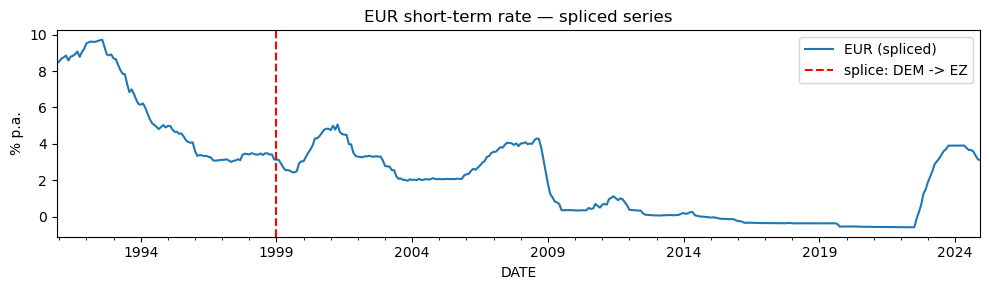

In [121]:
fig, ax = plt.subplots(figsize=(10, 3))

# EUR is in percent per year in your 'rates' dataframe
rates["EUR"].plot(ax=ax, label="EUR (spliced)")

# splice date (month end)
ax.axvline(pd.Timestamp("1999-01-31"), color="red", ls="--", label="splice: DEM -> EZ")

ax.set_title("EUR short-term rate — spliced series")
ax.set_ylabel("% p.a.")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save the processed panel

In [122]:
out_path = PROCESSED_DIR / 'monthly_panel.parquet'
panel.to_parquet(out_path)
panel.to_csv(PROCESSED_DIR / 'monthly_panel.csv')
print(f'Saved: {out_path}')
print(f'Saved: {PROCESSED_DIR / "monthly_panel.csv"}')
print(f'Shape: {panel.shape}')

Saved: /Users/alexandrevallet/Desktop/Investments/Investment-spring-project/data/processed/monthly_panel.parquet
Saved: /Users/alexandrevallet/Desktop/Investments/Investment-spring-project/data/processed/monthly_panel.csv
Shape: (409, 19)


---

**When `monthly_panel.parquet` is saved and the sanity checks pass, Part 1 is done.** Next up: Part 2 (currency excess returns and Table 1).

---

────────────────────────────────────────────────────────────────────────

## # Part 2 — Currency Excess Returns

────────────────────────────────────────────────────────────────────────

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

PROJECT_DIR   = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUT_DIR    = PROJECT_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

CURRENCIES = ['AUD', 'CAD', 'EUR', 'GBP', 'JPY', 'NZD']

# Evaluation and full return samples
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'
RET_START  = '1991-01-31'   # first return: uses Dec-1990 spot/rate

## 1. Load panel & compute excess returns

In [124]:
panel = pd.read_parquet(PROCESSED_DIR / 'monthly_panel.parquet')
panel.index = pd.to_datetime(panel.index)

# Compute excess returns: X^i_{t+1} = (S_{t+1}/S_t)*(1+r^i_t) - (1+r^US_t)
excess = pd.DataFrame(index=panel.index)

for c in CURRENCIES:
    S      = panel[f'S_{c}']
    r_for  = panel[f'r_{c}']
    r_us   = panel['r_USD']
    # shift(−1) gives S_{t+1}; excess return is indexed at t+1
    excess[f'X_{c}'] = (S.shift(-1) / S) * (1 + r_for) - (1 + r_us)

# Drop the last row (no S_{t+1} available) and trim to return sample
excess = excess.iloc[:-1]   # remove last NaN row
excess.index = excess.index + pd.offsets.MonthEnd(1)  # re-index to end of return month

# Keep full return sample Jan 1991 – Dec 2024
excess = excess.loc[RET_START:EVAL_END]

print('Full return sample:', excess.index[0].date(), '→', excess.index[-1].date())
print('Rows:', len(excess))
excess.head()

Full return sample: 1991-01-31 → 2024-12-31
Rows: 408


,X_AUD,X_CAD,X_EUR,X_GBP,X_JPY,X_NZD
month,,,,,,
1991-01-31,0.0185,0.0019,0.0202,0.0254,0.0346,0.0233
1991-02-28,0.0071,0.0149,-0.0330,-0.0233,-0.0125,0.0040
1991-03-31,-0.0106,-0.0035,-0.0981,-0.0846,-0.0535,-0.0178
1991-04-30,0.0160,0.0083,-0.0089,0.0017,0.0363,0.0095
1991-05-31,-0.0224,0.0106,-0.0128,-0.0141,-0.0154,-0.0063


*Persist the excess returns to a parquet file so subsequent parts can load them without re-computing.*

In [125]:
# Save excess returns for use by later notebooks
excess.to_parquet(PROCESSED_DIR / 'excess_returns.parquet')
print('Saved excess_returns.parquet')

Saved excess_returns.parquet


## 2. Table 1 — Summary statistics (evaluation sample Jan 1995 – Dec 2024)

In [126]:
X_eval  = excess.loc[EVAL_START:EVAL_END]           # 360 rows
panel_eval = panel.loc[EVAL_START:EVAL_END]          # for avg foreign rates

rows = {}
for c in CURRENCIES:
    x = X_eval[f'X_{c}'].dropna()
    N = len(x)

    mean_m  = x.mean()
    std_m   = x.std(ddof=1)
    mean_a  = mean_m * 12          # annualised mean (%)
    std_a   = std_m  * np.sqrt(12) # annualised std (%)
    t_stat  = mean_m / (std_m / np.sqrt(N))   # t-stat on monthly mean
    sr      = mean_a / std_a       # annualised Sharpe
    skew    = stats.skew(x, bias=False)
    kurt    = stats.kurtosis(x, bias=False)    # excess kurtosis

    # Average foreign risk-free rate (annualised %)
    avg_r_for = panel_eval[f'r_{c}'].mean() * 1200

    rows[c] = {
        'Mean (%, ann.)' : mean_a * 100,
        't-stat'         : t_stat,
        'Std (%, ann.)'  : std_a  * 100,
        'Sharpe ratio'   : sr,
        'Skewness'       : skew,
        'Excess kurtosis': kurt,
        'N obs'          : N,
        'Avg r_for (%, ann.)': avg_r_for,
    }

table1 = pd.DataFrame(rows).T
table1.index.name = 'Currency'

# Format display
fmt = {
    'Mean (%, ann.)'    : '{:.2f}',
    't-stat'            : '{:.2f}',
    'Std (%, ann.)'     : '{:.2f}',
    'Sharpe ratio'      : '{:.3f}',
    'Skewness'          : '{:.3f}',
    'Excess kurtosis'   : '{:.3f}',
    'N obs'             : '{:.0f}',
    'Avg r_for (%, ann.)': '{:.2f}',
}

print('\n===  TABLE 1 — Currency Excess Returns (Jan 1995 – Dec 2024)  ===\n')
print(table1.T.to_string(float_format=lambda x: f'{x:.3f}'))


===  TABLE 1 — Currency Excess Returns (Jan 1995 – Dec 2024)  ===

Currency                AUD     CAD     EUR     GBP     JPY     NZD
Mean (%, ann.)        1.408   0.334  -0.888   0.101  -3.302   2.258
t-stat                0.656   0.227  -0.527   0.067  -1.685   1.013
Std (%, ann.)        11.758   8.064   9.222   8.278  10.733  12.210
Sharpe ratio          0.120   0.041  -0.096   0.012  -0.308   0.185
Skewness             -0.192  -0.281   0.035  -0.206   0.658  -0.111
Excess kurtosis       1.303   2.912   1.214   1.222   3.254   1.242
N obs               360.000 360.000 360.000 360.000 360.000 360.000
Avg r_for (%, ann.)   3.968   2.586   1.750   3.001   0.140   4.459


*Export Table 1 (currency summary statistics) to CSV for inclusion in the report.*

In [127]:
# Export Table 1 to CSV
table1.to_csv(OUTPUT_DIR / 'table1_excess_returns.csv', float_format='%.4f')
print('Saved table1_excess_returns.csv')
table1.style.format(fmt)

Saved table1_excess_returns.csv


,"Mean (%, ann.)",t-stat,"Std (%, ann.)",Sharpe ratio,Skewness,Excess kurtosis,N obs,"Avg r_for (%, ann.)"
Currency,,,,,,,,
AUD,1.41,0.66,11.76,0.120,-0.192,1.303,360,3.97
CAD,0.33,0.23,8.06,0.041,-0.281,2.912,360,2.59
EUR,-0.89,-0.53,9.22,-0.096,0.035,1.214,360,1.75
GBP,0.10,0.07,8.28,0.012,-0.206,1.222,360,3.00
JPY,-3.30,-1.69,10.73,-0.308,0.658,3.254,360,0.14
NZD,2.26,1.01,12.21,0.185,-0.111,1.242,360,4.46


## 3. Plot cumulative excess returns (evaluation sample)

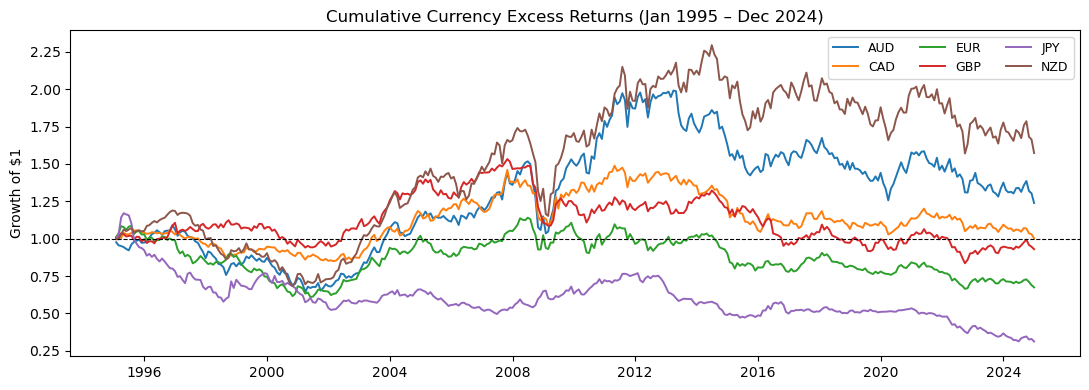

Saved fig_cumulative_excess_returns.pdf


In [128]:
cum_ret = (1 + X_eval[[f'X_{c}' for c in CURRENCIES]]).cumprod()
cum_ret.columns = CURRENCIES

fig, ax = plt.subplots(figsize=(11, 4))
for c in CURRENCIES:
    ax.plot(cum_ret.index, cum_ret[c], label=c, lw=1.4)

ax.axhline(1, color='black', lw=0.8, ls='--')
ax.set_title('Cumulative Currency Excess Returns (Jan 1995 – Dec 2024)')
ax.set_ylabel('Growth of $1')
ax.legend(ncol=3, fontsize=9)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_cumulative_excess_returns.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_cumulative_excess_returns.pdf')

## 4. Discussion (c) — Cross-sectional differences

Observations from Table 1:

- **Carry currencies (AUD, NZD):** These currencies exhibit the highest average foreign short-term rates (4.0% and 4.5% annualized respectively), and accordingly earn the highest positive excess returns (+1.4% and +2.3% annualized). This is consistent with the carry premium: high-yield currencies tend to appreciate — or at least not depreciate enough to offset the interest rate advantage — rewarding investors who go long.

- **Funding currency (JPY):** Japan's near-zero interest rate (avg. 0.14% annualized) makes the JPY the canonical carry funding currency. From a USD investor's perspective, going long JPY generates a mean excess return of −3.3% annualized — the worst in the cross-section — driven by the persistent carry disadvantage. Notably, JPY displays *positive* skewness (+0.658): a long JPY position occasionally produces large positive returns during sharp yen appreciation episodes (e.g., carry unwind events in 2008 and 2020). It is the *short* JPY carry strategy — not the long JPY position reported here — that bears the well-known negative skewness associated with carry crash risk.

- **Sharpe ratios:** All individual currencies post Sharpe ratios below 0.20 in absolute value, reflecting the high idiosyncratic volatility of unhedged FX positions relative to their modest average returns. This motivates building diversified factor portfolios (carry, momentum, dollar) rather than placing single-currency bets.

- **Statistical significance:** With t-statistics ranging from −1.69 (JPY) to +1.01 (NZD), no individual currency excess return is statistically distinguishable from zero at conventional thresholds. The signal-to-noise ratio is simply too low at the currency level over 360 monthly observations.

- **Fat tails:** Excess kurtosis is positive for all currencies (ranging from 1.2 to 3.3), confirming heavy-tailed return distributions consistent with periodic FX market dislocations and the well-documented crash risk in currency markets.

---

────────────────────────────────────────────────────────────────────────

## # Part 3 — Carry Strategies

────────────────────────────────────────────────────────────────────────

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

PROJECT_DIR   = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUT_DIR    = PROJECT_DIR / 'output'

CURRENCIES = ['AUD', 'CAD', 'EUR', 'GBP', 'JPY', 'NZD']
N = len(CURRENCIES)
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'

*Load the monthly panel and the precomputed excess returns; build the interest-rate-differential signal $\Delta r^i_t = r^i_t - r^{US}_t$ aligned with $X^i_{t+1}$ to avoid look-ahead bias.*

In [130]:
panel  = pd.read_parquet(PROCESSED_DIR / 'monthly_panel.parquet')
panel.index = pd.to_datetime(panel.index)

excess = pd.read_parquet(PROCESSED_DIR / 'excess_returns.parquet')
excess.index = pd.to_datetime(excess.index)

# Interest rate differential Δr^i_t = r^i_t - r^US_t  (signal formed at t)
delta_r = pd.DataFrame(
    {c: panel[f'r_{c}'] - panel['r_USD'] for c in CURRENCIES},
    index=panel.index
)

# Align signal (formed at t, month-end) with return (realised at t+1)
# excess is indexed at t+1; delta_r indexed at t → shift delta_r forward 1 month
delta_r_shifted = delta_r.shift(1)          # now indexed at t+1, contains signal from t
delta_r_shifted.index = delta_r.index       # keep original index for alignment

# Restrict to evaluation sample
X   = excess.loc[EVAL_START:EVAL_END][[f'X_{c}' for c in CURRENCIES]]
DR  = delta_r_shifted.loc[EVAL_START:EVAL_END]   # signal at t, for return at t+1

print('Excess returns:', X.shape)
print('Signal shape:  ', DR.shape)

Excess returns: (360, 6)
Signal shape:   (360, 6)


## (a) CS-CARRY and TS-CARRY returns

In [131]:
# ── CS-CARRY ──────────────────────────────────────────────────────────────────
# Rank currencies by Δr each month (rank 1 = lowest, rank N = highest)
ranks = DR.rank(axis=1, method='average')          # shape (360, 6)
raw_w = ranks - (N + 1) / 2                        # deviation from median rank

# Z: normalise so Σ positive weights = 1 each month
Z = 1.0 / raw_w.clip(lower=0).sum(axis=1)          # scalar per month
w_cs = raw_w.multiply(Z, axis=0)                   # self-financing weights
w_cs.columns = CURRENCIES

# Strategy return
X_vals = X.values
R_cs = (w_cs.values * X_vals).sum(axis=1)
R_cs = pd.Series(R_cs, index=X.index, name='CS-CARRY')

# ── TS-CARRY ──────────────────────────────────────────────────────────────────
w_ts = DR.apply(np.sign) / N
w_ts.columns = CURRENCIES

R_ts = (w_ts.values * X_vals).sum(axis=1)
R_ts = pd.Series(R_ts, index=X.index, name='TS-CARRY')

print(f'CS-CARRY: {len(R_cs)} obs, first {R_cs.index[0].date()}, last {R_cs.index[-1].date()}')
print(f'TS-CARRY: {len(R_ts)} obs')

CS-CARRY: 360 obs, first 1995-01-31, last 2024-12-31
TS-CARRY: 360 obs


*Compute the four headline performance statistics — annualised mean (%), t-stat, annualised standard deviation (%) and Sharpe ratio — and assemble the carry rows of Table 2.*

In [132]:
def perf_stats(series, label):
    """Annualised mean%, t-stat, std%, Sharpe."""
    r = series.dropna()
    n     = len(r)
    mu_m  = r.mean()
    sig_m = r.std(ddof=1)
    mu_a  = mu_m  * 12
    sig_a = sig_m * np.sqrt(12)
    tstat = mu_m / (sig_m / np.sqrt(n))
    sr    = mu_a / sig_a
    return pd.Series(
        [mu_a * 100, tstat, sig_a * 100, sr],
        index=['Mean (%, ann.)', 't-stat', 'Std (%, ann.)', 'Sharpe'],
        name=label
    )

stats_cs = perf_stats(R_cs, 'CS-CARRY')
stats_ts = perf_stats(R_ts, 'TS-CARRY')

table2_carry = pd.DataFrame([stats_cs, stats_ts]).T
print('\n=== TABLE 2 (carry rows) ===')
print(table2_carry.round(3).to_string())


=== TABLE 2 (carry rows) ===
                CS-CARRY  TS-CARRY
Mean (%, ann.)    3.6910    2.7720
t-stat            2.1660    2.5680
Std (%, ann.)     9.3340    5.9120
Sharpe            0.3950    0.4690


### Discussion (a) — Statistical significance of carry strategies

**Both carry strategies deliver statistically significant excess returns over the evaluation sample.**

- **CS-CARRY:** mean **3.69%** annualised, t-stat **2.17**, Sharpe **0.395**. Significant at the 5% level.
- **TS-CARRY:** mean **2.77%** annualised, t-stat **2.57**, Sharpe **0.469**. Significant at the 1% level.

Although CS-CARRY has a higher mean return, TS-CARRY has the better Sharpe ratio because its sign-based construction produces a much lower volatility (5.9% vs 9.3% annualised). The CS construction concentrates exposure on the extreme-rank currencies (long AUD/NZD, short JPY) and therefore carries more idiosyncratic risk.

This is the canonical empirical evidence on the FX carry premium and on the failure of Uncovered Interest Rate Parity: high-rate currencies do not depreciate enough to offset their interest-rate advantage, leaving a positive risk-adjusted return for carry traders.

## (b) CS-CARRY portfolio weights over time

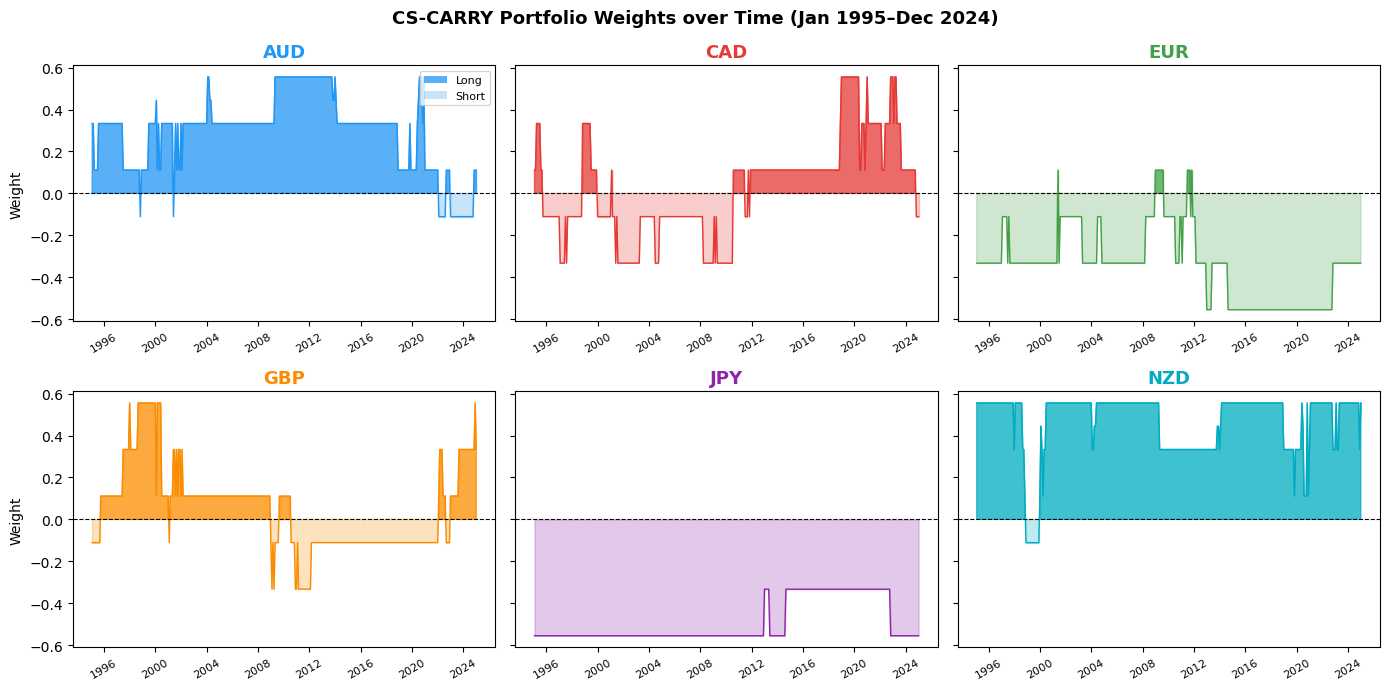

Saved fig_cscarry_weights.pdf


In [133]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes = axes.flatten()

COLORS = ['#2196F3', '#E53935', '#43A047', '#FB8C00', '#8E24AA', '#00ACC1']

for i, c in enumerate(CURRENCIES):
    ax  = axes[i]
    w   = w_cs[c]

    # filled areas: positive = long (darker), negative = short (lighter)
    ax.fill_between(w.index, w, 0,
                    where=(w >= 0), color=COLORS[i], alpha=0.75, label='Long')
    ax.fill_between(w.index, w, 0,
                    where=(w  < 0), color=COLORS[i], alpha=0.25, label='Short')
    ax.plot(w.index, w, color=COLORS[i], lw=1.0)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(c, fontsize=13, fontweight='bold', color=COLORS[i])
    ax.set_ylabel('Weight' if i % 3 == 0 else '')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

    # long / short legend on first panel only
    if i == 0:
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=COLORS[i], alpha=0.75, label='Long'),
                   Patch(facecolor=COLORS[i], alpha=0.25, label='Short')]
        ax.legend(handles=handles, fontsize=8, loc='upper right')

fig.suptitle('CS-CARRY Portfolio Weights over Time (Jan 1995\u2013Dec 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_cscarry_weights.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_cscarry_weights.pdf')

**Observations on CS-CARRY weights:**

- AUD and NZD (high-rate currencies) are persistently long — they consistently rank high on the interest rate differential.
- JPY (near-zero rate throughout) is persistently short — it almost always ranks lowest.
- EUR and CAD occupy intermediate ranks and switch sides over time as their rate differentials fluctuate.
- The weights are relatively stable over time, reflecting the persistence of interest rate differentials. Major regime shifts (2008 GFC, 2020 COVID) are visible as temporary weight rotations.

## (c) Forward discount vs. interest rate differential

In [134]:
# fd^i_t = log(S^i_t / F^i_t)  — net forward discount (in logs)
fd = pd.DataFrame(
    {c: np.log(panel[f'S_{c}'] / panel[f'F_{c}']) for c in CURRENCIES},
    index=panel.index
)

# Δr^i_t already computed above (not shifted)
corrs = {}
for c in CURRENCIES:
    common = pd.concat([fd[c], delta_r[c]], axis=1).dropna()
    corrs[c] = common.iloc[:, 0].corr(common.iloc[:, 1])

corr_series = pd.Series(corrs, name='Corr(fd, Δr)')
print('Time-series correlations between fd^i_t and Δr^i_t:')
print(corr_series.round(4).to_string())
print(f'\nCross-sectional average: {corr_series.mean():.4f}')

Time-series correlations between fd^i_t and Δr^i_t:
AUD   0.7929
CAD   0.7564
EUR   0.9443
GBP   0.8085
JPY   0.9730
NZD   0.8030

Cross-sectional average: 0.8463


**Theoretical justification:**

By Covered Interest Rate Parity (CIP), arbitrage in the forward market forces:
$$\frac{F^i_t}{S^i_t} = \frac{1 + r^{US}_t}{1 + r^i_t}$$

Inverting both sides gives:
$$\frac{S^i_t}{F^i_t} = \frac{1 + r^i_t}{1 + r^{US}_t}$$

Taking logs and using the approximation $\log(1+x) \approx x$ for small $x$:
$$fd^i_t = \log\frac{S^i_t}{F^i_t} = \log(1 + r^i_t) - \log(1 + r^{US}_t) \approx r^i_t - r^{US}_t = \Delta r^i_t$$

So the net forward discount $fd^i_t$ and the interest rate differential $\Delta r^i_t$ are theoretically identical up to a log-linear approximation — both measure the same carry signal from two different data sources (Datastream forward rates vs. FRED interest rates). The empirical cross-sectional average correlation of **0.85** is consistent with this prediction; the gap from unity reflects the log-level approximation error and minor timing or data-source mismatches between the two series.

*Save CS-CARRY and TS-CARRY return series, the CS-CARRY weight matrix, and the full $\Delta r$ panel for use in later parts.*

In [135]:
# Save carry returns and weights for later notebooks
carry_returns = pd.DataFrame({'CS-CARRY': R_cs, 'TS-CARRY': R_ts})
carry_returns.to_parquet(PROCESSED_DIR / 'carry_returns.parquet')

w_cs.to_parquet(PROCESSED_DIR / 'cscarry_weights.parquet')

# Save delta_r (full sample) for momentum notebook
delta_r.to_parquet(PROCESSED_DIR / 'delta_r.parquet')

print('Saved carry_returns.parquet, cscarry_weights.parquet, delta_r.parquet')

Saved carry_returns.parquet, cscarry_weights.parquet, delta_r.parquet


---

────────────────────────────────────────────────────────────────────────

## # Part 4 — Momentum Strategies

────────────────────────────────────────────────────────────────────────

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
import statsmodels.api as sm
from pathlib import Path

PROJECT_DIR   = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUT_DIR    = PROJECT_DIR / 'output'

CURRENCIES = ['AUD', 'CAD', 'EUR', 'GBP', 'JPY', 'NZD']
N = len(CURRENCIES)
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'

*Load the panel, the excess returns, and the previously computed carry returns.*

In [137]:
panel  = pd.read_parquet(PROCESSED_DIR / 'monthly_panel.parquet')
panel.index = pd.to_datetime(panel.index)
panel = panel.astype(float)

excess = pd.read_parquet(PROCESSED_DIR / 'excess_returns.parquet')
excess.index = pd.to_datetime(excess.index)
excess = excess.astype(float)

carry_ret = pd.read_parquet(PROCESSED_DIR / 'carry_returns.parquet')
carry_ret.index = pd.to_datetime(carry_ret.index)
carry_ret = carry_ret.astype(float)

## 1. Build momentum signal $s^i_{t-12,t}$ on the full sample

In [138]:
# s^i_{t-12,t} = S^i_t / S^i_{t-12} - 1
# Built on the full panel index (Dec 1990 – Dec 2024)
spot = panel[[f'S_{c}' for c in CURRENCIES]].copy()
spot.columns = CURRENCIES

mom_signal = spot / spot.shift(12) - 1   # indexed at t, uses S_{t} and S_{t-12}

# First valid signal: January 1992 (row 13, index 1992-01-31)
print('First valid signal row:')
print(mom_signal.dropna().head(2))
print(f'First valid signal date: {mom_signal.dropna().index[0].date()}')

First valid signal row:
               AUD     CAD     EUR     GBP    JPY     NZD
month                                                    
1991-12-31 -0.0162  0.0039 -0.0220 -0.0314 0.0865 -0.0816
1992-01-31 -0.0418 -0.0104 -0.0895 -0.0922 0.0432 -0.0984
First valid signal date: 1991-12-31


## 2. Align signal with returns (no lookahead)

In [139]:
# Return X^i_{t+1} is indexed at t+1 in our excess DataFrame.
# The signal used to form the portfolio at month t is s^i_{t-12,t}.
# So for return at t+1, we need mom_signal at t  →  shift signal by 1 month forward.

mom_signal_shifted = mom_signal.shift(1)   # at index t+1: contains signal from t
# (shift does NOT change the index — values shift, index stays same)

# Restrict both to evaluation sample
X   = excess.loc[EVAL_START:EVAL_END][[f'X_{c}' for c in CURRENCIES]]
MOM = mom_signal_shifted.loc[EVAL_START:EVAL_END]  # signal at t, for return at t+1
MOM.columns = CURRENCIES

# Verify: signal at Jan 1995 should come from Dec 1994 (s_{Dec94-12,Dec94} = S_Dec94/S_Dec93 - 1)
manual_sig_aud = panel.loc['1994-12-31','S_AUD'] / panel.loc['1993-12-31','S_AUD'] - 1
stored_sig_aud = MOM.loc['1995-01-31','AUD']
print(f'Manual momentum signal AUD at Jan 1995 (signal from Dec 1994): {manual_sig_aud:.6f}')
print(f'Stored momentum signal AUD at Jan 1995:                         {stored_sig_aud:.6f}')
print(f'Match: {np.isclose(manual_sig_aud, stored_sig_aud)}')
print(f'\nMissing values in MOM (eval sample): {MOM.isna().sum().sum()}')
print(f'Shape: {MOM.shape}')

Manual momentum signal AUD at Jan 1995 (signal from Dec 1994): 0.142006
Stored momentum signal AUD at Jan 1995:                         0.142006
Match: True

Missing values in MOM (eval sample): 0
Shape: (360, 6)


## 3. (a) Construct CS-MOM and TS-MOM returns

In [140]:
def cs_weights(signal_df, N):
    """Cross-sectional rank weights: Z*(rank - (N+1)/2), sum positive = 1."""
    ranks = signal_df.rank(axis=1, method='average')
    raw   = ranks - (N + 1) / 2
    Z     = 1.0 / raw.clip(lower=0).sum(axis=1)
    return raw.multiply(Z, axis=0)

def ts_weights(signal_df, N):
    """Time-series sign weights: sign(signal) / N."""
    return signal_df.apply(np.sign) / N

def strat_return(weights, returns):
    """Portfolio return: sum of w^i * X^i each month."""
    w = weights.copy()
    w.columns = returns.columns   # align columns
    return (w.values * returns.values).sum(axis=1)

# Build CS-MOM
w_cs_mom = cs_weights(MOM, N)
R_cs_mom = pd.Series(
    strat_return(w_cs_mom, X),
    index=X.index, name='CS-MOM'
)

# Build TS-MOM
w_ts_mom = ts_weights(MOM, N)
R_ts_mom = pd.Series(
    strat_return(w_ts_mom, X),
    index=X.index, name='TS-MOM'
)

print(f'CS-MOM: {len(R_cs_mom)} obs, {R_cs_mom.index[0].date()} → {R_cs_mom.index[-1].date()}')
print(f'TS-MOM: {len(R_ts_mom)} obs')
print(f'NaN in CS-MOM: {R_cs_mom.isna().sum()}')
print(f'NaN in TS-MOM: {R_ts_mom.isna().sum()}')

CS-MOM: 360 obs, 1995-01-31 → 2024-12-31
TS-MOM: 360 obs
NaN in CS-MOM: 0
NaN in TS-MOM: 0


*Compute the momentum performance stats and combine them with the carry stats to form the partial Table 2 (carry + momentum rows).*

In [141]:
def perf_stats(series, label):
    r = series.dropna()
    n = len(r)
    mu_m  = r.mean()
    sig_m = r.std(ddof=1)
    mu_a  = mu_m  * 12
    sig_a = sig_m * np.sqrt(12)
    tstat = mu_m / (sig_m / np.sqrt(n))
    sr    = mu_a / sig_a
    return pd.Series(
        [mu_a * 100, tstat, sig_a * 100, sr],
        index=['Mean (%, ann.)', 't-stat', 'Std (%, ann.)', 'Sharpe'],
        name=label
    )

stats_cs_mom = perf_stats(R_cs_mom, 'CS-MOM')
stats_ts_mom = perf_stats(R_ts_mom, 'TS-MOM')

# Also reload carry stats for comparison
R_cs_carry = carry_ret['CS-CARRY']
R_ts_carry = carry_ret['TS-CARRY']
stats_cs_carry = perf_stats(R_cs_carry, 'CS-CARRY')
stats_ts_carry = perf_stats(R_ts_carry, 'TS-CARRY')

table2_partial = pd.DataFrame([stats_cs_carry, stats_ts_carry,
                                stats_cs_mom,   stats_ts_mom]).T

print('\n=== TABLE 2 (carry + momentum rows) ===')
print(table2_partial.round(3).to_string())


=== TABLE 2 (carry + momentum rows) ===
                CS-CARRY  TS-CARRY  CS-MOM  TS-MOM
Mean (%, ann.)    3.6910    2.7720  0.2350  1.5640
t-stat            2.1660    2.5680  0.1530  1.2930
Std (%, ann.)     9.3340    5.9120  8.4050  6.6240
Sharpe            0.3950    0.4690  0.0280  0.2360


### Discussion (a) — Statistical significance of momentum strategies

**An investor following either of these strategies would NOT have earned a statistically significant return.**

- **CS-MOM:** annualised mean of only **0.24%** with a t-statistic of **0.15** — economically and statistically indistinguishable from zero. Sharpe ratio is **0.028**.
- **TS-MOM:** annualised mean of **1.56%** with a t-statistic of **1.29**, well below the 5% significance threshold of 1.96. Sharpe ratio is **0.236**.

Compared to the carry strategies (CS-CARRY t = 2.17, TS-CARRY t = 2.57, both significant), **momentum is much weaker in the FX cross-section**. This finding is consistent with the empirical literature (Menkhoff et al., 2012): equity-style momentum does not transplant cleanly to currencies, partly because FX trends are interrupted more frequently by central-bank interventions and macroeconomic news shocks.

TS-MOM still beats CS-MOM in Sharpe terms (0.24 vs 0.03) because the sign-based construction has lower volatility (6.6% vs 8.4% annualised) — the same pattern observed for the carry strategies.

## 4. (b) Regression of TS-CARRY on CS-MOM + TS-MOM

In [142]:
# OLS: R^TS-CARRY = α + β1*R^CS-MOM + β2*R^TS-MOM + ε
# Use Newey-West (HAC) standard errors with 12 lags — standard for monthly financial returns

df_reg = pd.DataFrame({
    'TS_CARRY' : R_ts_carry,
    'CS_MOM'   : R_cs_mom,
    'TS_MOM'   : R_ts_mom,
}).dropna()

y = df_reg['TS_CARRY']
X_reg = sm.add_constant(df_reg[['CS_MOM', 'TS_MOM']])

model = sm.OLS(y, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               TS_CARRY   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.03630
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.964
Time:                        21:10:26   Log-Likelihood:                 955.24
No. Observations:                 360   AIC:                            -1904.
Df Residuals:                     357   BIC:                            -1893.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      2.788      0.0

*Compare the standalone t-stat on $E[R^{TS-CARRY}]$ to the intercept t-stat from the regression to identify whether momentum improves carry through higher mean or lower variance.*

In [143]:
# Standalone t-stat on TS-CARRY mean (from perf_stats above)
tstat_standalone = stats_ts_carry['t-stat']
tstat_intercept  = model.tvalues['const']
alpha_annualised = model.params['const'] * 12 * 100  # in %

print('=== Key comparison ===')
print(f'Standalone t-stat on E[TS-CARRY]:      {tstat_standalone:.3f}')
print(f'Intercept t-stat after MOM controls:   {tstat_intercept:.3f}')
print(f'Alpha (annualised %):                  {alpha_annualised:.2f}%')
print(f'R²:                                    {model.rsquared:.4f}')
print()
print('Coefficients and NW t-stats:')
summary = pd.DataFrame({
    'coef'  : model.params,
    't-stat': model.tvalues,
    'p-val' : model.pvalues,
})
print(summary.round(4).to_string())

=== Key comparison ===
Standalone t-stat on E[TS-CARRY]:      2.568
Intercept t-stat after MOM controls:   2.788
Alpha (annualised %):                  2.77%
R²:                                    0.0008

Coefficients and NW t-stats:
         coef  t-stat  p-val
const  0.0023  2.7882 0.0053
CS_MOM 0.0196  0.2693 0.7877
TS_MOM 0.0013  0.0070 0.9944


### Discussion (b) — Regression interpretation

**Estimated regression** (HAC standard errors, 12 lags):

| Coefficient | Estimate | t-stat | p-value |
|---|---|---|---|
| α (annualised) | 2.77% | **2.79** | 0.005 |
| β₁ (CS-MOM) | 0.020 | 0.27 | 0.788 |
| β₂ (TS-MOM) | 0.001 | 0.01 | 0.994 |
| R² | 0.08% | — | — |

**Comparison of t-stats on the carry premium:**

| Specification | α (ann. %) | t-stat |
|---|---|---|
| Standalone E[TS-CARRY] | 2.77% | 2.57 |
| Controlling for CS-MOM + TS-MOM | 2.77% | **2.79** |

**Channel: lower variance, NOT higher mean.**

The intercept t-statistic *rises* from 2.57 to 2.79 even though the alpha itself is essentially unchanged (2.77% in both specifications). Two channels could move the t-stat:
1. Higher residual mean — does *not* happen here: $\hat{\alpha}$ is virtually identical to the standalone mean.
2. Lower residual variance — this is the active channel: the momentum regressors absorb a small amount of TS-CARRY variance, tightening the standard error on $\hat{\alpha}$.

**However, the improvement is economically marginal.** R² of only 0.08% means CS-MOM and TS-MOM explain almost none of TS-CARRY's variance, and the momentum coefficients are individually insignificant (both |t| < 0.3). Adding momentum as a hedge does not meaningfully improve a carry portfolio: the carry premium is essentially **orthogonal** to the momentum factors over this sample. This consistent with the weak standalone performance of CS-MOM and TS-MOM documented in part (a).

*Persist the CS-MOM and TS-MOM return series and the unshifted momentum signal for use in the dollar and OOS sections.*

In [144]:
# Save momentum returns and signal for later notebooks
mom_returns = pd.DataFrame({'CS-MOM': R_cs_mom, 'TS-MOM': R_ts_mom})
mom_returns.to_parquet(PROCESSED_DIR / 'mom_returns.parquet')

# Save the full (unshifted) momentum signal for later use (OOS section)
mom_signal.to_parquet(PROCESSED_DIR / 'mom_signal.parquet')

print('Saved mom_returns.parquet and mom_signal.parquet')

Saved mom_returns.parquet and mom_signal.parquet


---

────────────────────────────────────────────────────────────────────────

## # Part 5 — Dollar Strategies

────────────────────────────────────────────────────────────────────────

In [145]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

PROJECT_DIR   = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUT_DIR    = PROJECT_DIR / 'output'

CURRENCIES = ['AUD', 'CAD', 'EUR', 'GBP', 'JPY', 'NZD']
N = len(CURRENCIES)
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'

*Load all inputs and build the cross-currency average rate differential $\bar{\Delta r}_t$ shifted by one month so the signal at $t$ aligns with the return at $t+1$.*

In [146]:
panel     = pd.read_parquet(PROCESSED_DIR / 'monthly_panel.parquet').astype(float)
panel.index = pd.to_datetime(panel.index)

excess    = pd.read_parquet(PROCESSED_DIR / 'excess_returns.parquet').astype(float)
excess.index = pd.to_datetime(excess.index)

carry_ret = pd.read_parquet(PROCESSED_DIR / 'carry_returns.parquet').astype(float)
carry_ret.index = pd.to_datetime(carry_ret.index)

mom_ret   = pd.read_parquet(PROCESSED_DIR / 'mom_returns.parquet').astype(float)
mom_ret.index = pd.to_datetime(mom_ret.index)

# Evaluation-sample excess returns (360 x 6)
X = excess.loc[EVAL_START:EVAL_END][[f'X_{c}' for c in CURRENCIES]]

# Interest-rate differential signal at t, shifted to align with t+1 return
delta_r     = pd.DataFrame({c: panel[f'r_{c}'] - panel['r_USD'] for c in CURRENCIES}, index=panel.index)
delta_r_avg = delta_r.mean(axis=1)
DR_avg      = delta_r_avg.shift(1).loc[EVAL_START:EVAL_END]

print(f'X shape:      {X.shape}  — expect (360, 6)')
print(f'DR_avg shape: {DR_avg.shape}  — expect (360,)')
print(f'NaN in X:     {X.isna().sum().sum()}')
print(f'NaN in DR_avg:{DR_avg.isna().sum()}')

X shape:      (360, 6)  — expect (360, 6)
DR_avg shape: (360,)  — expect (360,)
NaN in X:     0
NaN in DR_avg:0


## Alignment verification (no lookahead)

In [147]:
# Signal for Jan-1995 return must be delta_r_avg at Dec-1994
manual = delta_r.loc['1994-12-31'].mean()
stored = DR_avg.loc['1995-01-31']
print(f'delta_r_avg Dec-1994 (manual): {manual:.8f}')
print(f'delta_r_avg stored  Jan-1995:  {stored:.8f}')
assert np.isclose(manual, stored), 'Lookahead bias detected!'
print('OK - no lookahead')

delta_r_avg Dec-1994 (manual): 0.00012431
delta_r_avg stored  Jan-1995:  0.00012431
OK - no lookahead


## (a) DOLLAR and DOLLAR-CARRY

In [148]:
# DOLLAR: weight 1/N on each currency, always long
w_dollar = pd.DataFrame(np.full((len(X), N), 1.0/N), index=X.index, columns=CURRENCIES)
R_dollar = pd.Series((w_dollar.values * X.values).sum(axis=1), index=X.index, name='DOLLAR')

# DOLLAR-CARRY: weight sign(delta_r_avg)/N on each currency
sign_dr = np.sign(DR_avg)
w_dc    = pd.DataFrame(np.outer(sign_dr.values, np.ones(N)/N), index=X.index, columns=CURRENCIES)
R_dc    = pd.Series((w_dc.values * X.values).sum(axis=1), index=X.index, name='DOLLAR-CARRY')

print(f'DOLLAR obs: {len(R_dollar)}, NaN={R_dollar.isna().sum()}')
print(f'DOLLAR-CARRY obs: {len(R_dc)}, NaN={R_dc.isna().sum()}')
print(f'Months long basket (delta_r_avg > 0): {(sign_dr>0).sum()} ({(sign_dr>0).mean()*100:.0f}%)')
print(f'Months short basket (delta_r_avg < 0): {(sign_dr<0).sum()} ({(sign_dr<0).mean()*100:.0f}%)')

DOLLAR obs: 360, NaN=0
DOLLAR-CARRY obs: 360, NaN=0
Months long basket (delta_r_avg > 0): 179 (50%)
Months short basket (delta_r_avg < 0): 181 (50%)


*Manual checkpoint: verify the DOLLAR and DOLLAR-CARRY returns for January 1995 against a hand-computation, and confirm the structural identity $|R^{DOLLAR}| = |R^{DOLLAR-CARRY}|$ that holds because both strategies invest in the same basket up to a flipped sign.*

In [149]:
# Manual check Jan-1995
x_jan95   = X.loc['1995-01-31'].values
dollar_m  = x_jan95.mean()
sign_jan95 = float(np.sign(DR_avg.loc['1995-01-31']))
dc_m       = sign_jan95 * x_jan95.mean()
print(f'DOLLAR Jan-1995  manual={dollar_m:.8f}  stored={R_dollar.loc["1995-01-31"]:.8f}  match={np.isclose(dollar_m, R_dollar.loc["1995-01-31"])}')
print(f'sign(delta_r_avg) Jan-1995: {sign_jan95}')
print(f'DOLLAR-CARRY Jan-1995 manual={dc_m:.8f}  stored={R_dc.loc["1995-01-31"]:.8f}  match={np.isclose(dc_m, R_dc.loc["1995-01-31"])}')

# Structural check: |DOLLAR| == |DOLLAR-CARRY| always
assert np.allclose(R_dollar.abs().values, R_dc.abs().values)
print('OK - |DOLLAR| == |DOLLAR-CARRY| always (same basket, flipped sign when avg diff < 0)')

DOLLAR Jan-1995  manual=-0.00167085  stored=-0.00167085  match=True
sign(delta_r_avg) Jan-1995: 1.0
DOLLAR-CARRY Jan-1995 manual=-0.00167085  stored=-0.00167085  match=True
OK - |DOLLAR| == |DOLLAR-CARRY| always (same basket, flipped sign when avg diff < 0)


*Build the final Table 2 with all six factor strategies (CS-CARRY, TS-CARRY, CS-MOM, TS-MOM, DOLLAR, DOLLAR-CARRY) side-by-side.*

In [150]:
def perf_stats(series, label):
    r = series.dropna().astype(float)
    n     = len(r)
    mu_m  = r.mean()
    sig_m = r.std(ddof=1)
    mu_a  = mu_m  * 12
    sig_a = sig_m * np.sqrt(12)
    tstat = mu_m / (sig_m / np.sqrt(n))
    sr    = mu_a / sig_a
    return pd.Series([mu_a*100, tstat, sig_a*100, sr],
                     index=['Mean (%, ann.)', 't-stat', 'Std (%, ann.)', 'Sharpe'], name=label)

all_strats = [
    ('CS-CARRY',     carry_ret['CS-CARRY']),
    ('TS-CARRY',     carry_ret['TS-CARRY']),
    ('CS-MOM',       mom_ret['CS-MOM']),
    ('TS-MOM',       mom_ret['TS-MOM']),
    ('DOLLAR',       R_dollar),
    ('DOLLAR-CARRY', R_dc),
]

table2 = pd.DataFrame([perf_stats(r, n) for n, r in all_strats]).T
print('=== TABLE 2 — All six factor strategies ===')
print(table2.round(3).to_string())

=== TABLE 2 — All six factor strategies ===
                CS-CARRY  TS-CARRY  CS-MOM  TS-MOM  DOLLAR  DOLLAR-CARRY
Mean (%, ann.)    3.6910    2.7720  0.2350  1.5640 -0.0150        2.1280
t-stat            2.1660    2.5680  0.1530  1.2930 -0.0110        1.5430
Std (%, ann.)     9.3340    5.9120  8.4050  6.6240  7.5790        7.5540
Sharpe            0.3950    0.4690  0.0280  0.2360 -0.0020        0.2820


### Discussion (a)

**DOLLAR** takes a permanent long position in all six foreign currencies each month. Over the evaluation sample (Jan 1995 - Dec 2024), its mean excess return is essentially zero (-0.015% annualized, t-stat = -0.01), indicating that the USD neither appreciated nor depreciated significantly against the equal-weighted G10 basket on average. The strategy also carries the highest idiosyncratic risk of all six factors (vol ~7.6% annualized) because it takes the same directional bet every month with no conditioning signal. The near-zero Sharpe ratio (-0.002) confirms that naively going long all currencies offered no reward over this period.

**DOLLAR-CARRY** conditions on whether the average G10 rate differential $\bar{\Delta r}_t$ is positive or negative, flipping the basket position accordingly. By avoiding foreign currency exposure when US rates lead the G10 average, the strategy earns a mean of +2.13% annualized (Sharpe 0.28) - a meaningful improvement over the unconditional DOLLAR. However, with a t-stat of 1.54, the premium is not statistically significant at conventional thresholds, suggesting that the average cross-G10 rate differential is an imprecise predictor of broad USD direction. The near-perfect 50/50 split between long and short months (179 vs 181) also highlights that the conditioning signal switches frequently.

## (b) Extended regression: TS-CARRY ~ CS-MOM + TS-MOM + DOLLAR

In [151]:
R_ts_carry = carry_ret['TS-CARRY']
R_cs_mom   = mom_ret['CS-MOM']
R_ts_mom   = mom_ret['TS-MOM']

# 2-regressor model (from momentum notebook) for comparison
df1 = pd.DataFrame({'TS_CARRY':R_ts_carry,'CS_MOM':R_cs_mom,'TS_MOM':R_ts_mom}).dropna()
mod1 = sm.OLS(df1['TS_CARRY'], sm.add_constant(df1[['CS_MOM','TS_MOM']])).fit(cov_type='HAC', cov_kwds={'maxlags':12})

# 3-regressor model (add DOLLAR)
df2 = pd.DataFrame({'TS_CARRY':R_ts_carry,'CS_MOM':R_cs_mom,'TS_MOM':R_ts_mom,'DOLLAR':R_dollar}).dropna()
mod2 = sm.OLS(df2['TS_CARRY'], sm.add_constant(df2[['CS_MOM','TS_MOM','DOLLAR']])).fit(cov_type='HAC', cov_kwds={'maxlags':12})

print(mod2.summary())

                            OLS Regression Results                            
Dep. Variable:               TS_CARRY   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     4.244
Date:                Mon, 04 May 2026   Prob (F-statistic):            0.00578
Time:                        21:10:26   Log-Likelihood:                 986.64
No. Observations:                 360   AIC:                            -1965.
Df Residuals:                     356   BIC:                            -1950.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.001      3.018      0.0

*Compare the three nested specifications — standalone TS-CARRY, +MOM, and +MOM+DOLLAR — to isolate the share of TS-CARRY variance explained by the dollar factor.*

In [152]:
r_ts = R_ts_carry.dropna()
t_stand = r_ts.mean() / (r_ts.std(ddof=1) / np.sqrt(len(r_ts)))

compare = pd.DataFrame({
    'Standalone'  : [r_ts.mean()*12*100,  t_stand,                     float('nan')],
    '+MOM'        : [mod1.params['const']*12*100, mod1.tvalues['const'], mod1.rsquared],
    '+MOM+DOLLAR' : [mod2.params['const']*12*100, mod2.tvalues['const'], mod2.rsquared],
}, index=['alpha (ann %)', 't(alpha)', 'R2'])

print('=== Comparison: standalone vs +MOM vs +MOM+DOLLAR ===')
print(compare.round(4).to_string())
print()
print('=== Coefficients (3-regressor model) ===')
coef_df = pd.DataFrame({'coef': mod2.params, 't-stat': mod2.tvalues, 'p-val': mod2.pvalues})
print(coef_df.round(4).to_string())
print(f'R2 = {mod2.rsquared:.4f}')

=== Comparison: standalone vs +MOM vs +MOM+DOLLAR ===
               Standalone   +MOM  +MOM+DOLLAR
alpha (ann %)      2.7724 2.7658       2.6472
t(alpha)           2.5684 2.7882       3.0182
R2                    NaN 0.0008       0.1608

=== Coefficients (3-regressor model) ===
         coef  t-stat  p-val
const  0.0022  3.0182 0.0025
CS_MOM 0.0193  0.2987 0.7652
TS_MOM 0.0802  0.6288 0.5295
DOLLAR 0.3195  2.4942 0.0126
R2 = 0.1608


### Discussion (b)

Adding DOLLAR to the regression dramatically changes the picture compared to the MOM-only model:

**R² jumps from 0.08% to 16.1%.** The DOLLAR factor explains a substantial share of TS-CARRY variance. This makes economic sense: a sign-weighted carry strategy is structurally long on high-rate currencies (AUD, NZD, GBP) and short on low-rate ones (JPY). When the USD weakens globally, all foreign currencies tend to appreciate together, lifting both DOLLAR and TS-CARRY simultaneously - hence the positive and significant loading $\hat{\beta}_{DOLLAR} = 0.32$ (t = 2.49).

**The carry alpha is barely affected.** The annualized alpha falls only slightly from 2.77% to 2.65%, while its t-statistic *rises* from 2.57 (standalone) to 3.02 (+MOM+DOLLAR). This tells us that dollar risk does **not** explain the carry premium - it merely absorbed residual variance, making the alpha estimate more precise. The carry premium is thus a genuine risk-adjusted return, distinct from both momentum and dollar exposure.

**MOM coefficients remain insignificant** ($\beta_{CS-MOM} = 0.02$, $\beta_{TS-MOM} = 0.08$, both t < 1). TS-CARRY is orthogonal to momentum in expected return terms, confirming that the three factor families (carry, momentum, dollar) capture distinct sources of FX risk premia.

*Save the DOLLAR/DOLLAR-CARRY return series and export the final Table 2 to CSV.*

In [153]:
# Save dollar returns and Table 2
dollar_returns = pd.DataFrame({'DOLLAR': R_dollar, 'DOLLAR-CARRY': R_dc})
dollar_returns.to_parquet(PROCESSED_DIR / 'dollar_returns.parquet')
table2.to_csv(OUTPUT_DIR / 'table2_factor_strategies.csv', float_format='%.4f')
print('Saved dollar_returns.parquet and table2_factor_strategies.csv')

Saved dollar_returns.parquet and table2_factor_strategies.csv


---

────────────────────────────────────────────────────────────────────────

## # Part 6 — In-sample Portfolio Analysis

────────────────────────────────────────────────────────────────────────

**Evaluation sample:** January 1995 – December 2024 (360 obs)

**Building blocks:**
- 6 basis currency excess returns: $\{X^i_{t+1}\}_{i=1}^6$
- 6 factor strategies: CS-CARRY, TS-CARRY, CS-MOM, TS-MOM, DOLLAR, DOLLAR-CARRY

**Three weighting schemes applied to each set:**
- **EW**: equal-weight (1/N)
- **RP**: risk-parity (weights ∝ 1/σ_i, full in-sample σ)
- **MV**: mean-variance (w* ∝ Σ̂⁻¹μ̂, full in-sample moments)

All portfolios scaled to **10% annualised volatility** using the full in-sample σ.

**→ Table 3**: mean (ann %, 10%-vol scaled), t-stat, std (ann % = 10% by construction), Sharpe

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FACTORS    = ['CS-CARRY', 'TS-CARRY', 'CS-MOM', 'TS-MOM', 'DOLLAR', 'DOLLAR-CARRY']
N          = 6
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'
TARGET_VOL = 0.10   # 10% annualised

*Load the six currency excess returns and the six factor returns, and verify the structural identity EW-CCY = DOLLAR (Hint from Section 7(e) of the project).*

In [155]:
excess     = pd.read_parquet(PROCESSED_DIR / 'excess_returns.parquet').astype(float)
carry_ret  = pd.read_parquet(PROCESSED_DIR / 'carry_returns.parquet').astype(float)
mom_ret    = pd.read_parquet(PROCESSED_DIR / 'mom_returns.parquet').astype(float)
dollar_ret = pd.read_parquet(PROCESSED_DIR / 'dollar_returns.parquet').astype(float)
for df in [excess, carry_ret, mom_ret, dollar_ret]:
    df.index = pd.to_datetime(df.index)

# Evaluation-sample currency excess returns (360 x 6)
X = excess.loc[EVAL_START:EVAL_END][[f'X_{c}' for c in CURRENCIES]].copy()
X.columns = CURRENCIES

# Evaluation-sample factor returns (360 x 6), in FACTORS order
F = pd.concat([carry_ret, mom_ret, dollar_ret], axis=1).loc[EVAL_START:EVAL_END][FACTORS].copy()

assert X.shape == (360, 6) and F.shape == (360, 6)
assert X.isna().sum().sum() == 0 and F.isna().sum().sum() == 0
print(f'X: {X.shape}  F: {F.shape}  — no NaN, correct shapes')

# Confirm EW-CCY == DOLLAR
ew_ccy_ret = X.mean(axis=1)
assert np.allclose(ew_ccy_ret.values, dollar_ret['DOLLAR'].values)
print('Confirmed: EW-CCY = DOLLAR (by construction)')

X: (360, 6)  F: (360, 6)  — no NaN, correct shapes
Confirmed: EW-CCY = DOLLAR (by construction)


## Portfolio construction helpers

In [156]:
def ew_weights(returns_df):
    n = returns_df.shape[1]
    return np.ones(n) / n

def rp_weights(returns_df):
    sig = returns_df.std(ddof=1).values
    inv_sig = 1.0 / sig
    return inv_sig / inv_sig.sum()

def mv_weights(returns_df):
    mu  = returns_df.mean().values
    Sig = returns_df.cov().values
    return np.linalg.solve(Sig, mu)

def portfolio_returns(returns_df, weights):
    return pd.Series(returns_df.values @ weights, index=returns_df.index)

def scale_to_target_vol(ret_series, target=TARGET_VOL):
    sig_ann = ret_series.std(ddof=1) * np.sqrt(12)
    k = target / sig_ann
    return ret_series * k, k

def perf_stats(ret_series, label):
    r = ret_series.dropna()
    n     = len(r)
    mu_m  = r.mean()
    sig_m = r.std(ddof=1)
    mu_a  = mu_m  * 12
    sig_a = sig_m * np.sqrt(12)
    tstat = mu_m / (sig_m / np.sqrt(n))
    sr    = mu_a / sig_a
    return pd.Series(
        [mu_a * 100, tstat, sig_a * 100, sr],
        index=['Mean (%, ann.)', 't-stat', 'Std (%, ann.)', 'Sharpe'],
        name=label
    )

print('Portfolio construction functions defined.')

Portfolio construction functions defined.


## (a) Currency portfolios — EW, RP, MV

In [157]:
# EW-CCY
w_ew_ccy = ew_weights(X)
r_ew_ccy_raw = portfolio_returns(X, w_ew_ccy)
r_ew_ccy, k_ew_ccy = scale_to_target_vol(r_ew_ccy_raw)

# RP-CCY
w_rp_ccy = rp_weights(X)
r_rp_ccy_raw = portfolio_returns(X, w_rp_ccy)
r_rp_ccy, k_rp_ccy = scale_to_target_vol(r_rp_ccy_raw)

# MV-CCY
w_mv_ccy_raw = mv_weights(X)
r_mv_ccy_raw = portfolio_returns(X, w_mv_ccy_raw)
r_mv_ccy, k_mv_ccy = scale_to_target_vol(r_mv_ccy_raw)

print('=== Currency portfolio weights ===')
for name, w in [('EW-CCY', w_ew_ccy), ('RP-CCY', w_rp_ccy), ('MV-CCY (raw)', w_mv_ccy_raw)]:
    print(f'{name}: {np.round(w, 4)}  sum={w.sum():.4f}')

print()
print('=== Scaling factors (unscaled ann vol) ===')
for name, r_raw, k in [('EW-CCY', r_ew_ccy_raw, k_ew_ccy),
                        ('RP-CCY', r_rp_ccy_raw, k_rp_ccy),
                        ('MV-CCY', r_mv_ccy_raw, k_mv_ccy)]:
    print(f'{name}: k={k:.4f}, unscaled vol={r_raw.std(ddof=1)*np.sqrt(12)*100:.2f}%')

print()
print('=== Post-scaling vol (should all be 10.00%) ===')
for name, r in [('EW-CCY', r_ew_ccy), ('RP-CCY', r_rp_ccy), ('MV-CCY', r_mv_ccy)]:
    vol = r.std(ddof=1) * np.sqrt(12) * 100
    assert np.isclose(vol, 10.0, atol=1e-6)
    print(f'  {name}: {vol:.4f}%')

=== Currency portfolio weights ===
EW-CCY: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]  sum=1.0000
RP-CCY: [0.1387 0.2022 0.1768 0.1969 0.1519 0.1335]  sum=1.0000
MV-CCY (raw): [ 0.1934 -1.4609 -2.9292  0.3837 -3.1237  3.9413]  sum=-2.9954

=== Scaling factors (unscaled ann vol) ===
EW-CCY: k=1.3195, unscaled vol=7.58%
RP-CCY: k=1.3625, unscaled vol=7.34%
MV-CCY: k=0.2150, unscaled vol=46.52%

=== Post-scaling vol (should all be 10.00%) ===
  EW-CCY: 10.0000%
  RP-CCY: 10.0000%
  MV-CCY: 10.0000%


## (b) Factor portfolios — EW, RP, MV

In [158]:
# EW-FAC
w_ew_fac = ew_weights(F)
r_ew_fac_raw = portfolio_returns(F, w_ew_fac)
r_ew_fac, k_ew_fac = scale_to_target_vol(r_ew_fac_raw)

# RP-FAC
w_rp_fac = rp_weights(F)
r_rp_fac_raw = portfolio_returns(F, w_rp_fac)
r_rp_fac, k_rp_fac = scale_to_target_vol(r_rp_fac_raw)

# MV-FAC
w_mv_fac_raw = mv_weights(F)
r_mv_fac_raw = portfolio_returns(F, w_mv_fac_raw)
r_mv_fac, k_mv_fac = scale_to_target_vol(r_mv_fac_raw)

print('=== Factor portfolio weights ===')
for name, w in [('EW-FAC', w_ew_fac), ('RP-FAC', w_rp_fac), ('MV-FAC (raw)', w_mv_fac_raw)]:
    print(f'{name}: {np.round(w, 4)}  sum={w.sum():.4f}')

print()
print('=== Post-scaling vol (should all be 10.00%) ===')
for name, r in [('EW-FAC', r_ew_fac), ('RP-FAC', r_rp_fac), ('MV-FAC', r_mv_fac)]:
    vol = r.std(ddof=1) * np.sqrt(12) * 100
    assert np.isclose(vol, 10.0, atol=1e-6)
    print(f'  {name}: {vol:.4f}%')

=== Factor portfolio weights ===
EW-FAC: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]  sum=1.0000
RP-FAC: [0.1322 0.2087 0.1468 0.1863 0.1628 0.1633]  sum=1.0000
MV-FAC (raw): [ 2.9216  6.8575 -2.0926  4.9978 -2.7384 -0.6048]  sum=9.3409

=== Post-scaling vol (should all be 10.00%) ===
  EW-FAC: 10.0000%
  RP-FAC: 10.0000%
  MV-FAC: 10.0000%


## Table 3 — In-sample portfolios (scaled to 10% vol)

In [159]:
portfolios = [
    ('EW-CCY',  r_ew_ccy),
    ('RP-CCY',  r_rp_ccy),
    ('MV-CCY',  r_mv_ccy),
    ('EW-FAC',  r_ew_fac),
    ('RP-FAC',  r_rp_fac),
    ('MV-FAC',  r_mv_fac),
]

table3 = pd.DataFrame([perf_stats(r, n) for n, r in portfolios]).T
print('=== TABLE 3 — In-sample portfolios (scaled to 10% vol) ===')
print(table3.round(3).to_string())

# Cross-check: Sharpe invariant to vol-scaling
for name, r_raw, r_sc in [('EW-CCY', r_ew_ccy_raw, r_ew_ccy),
                           ('RP-CCY', r_rp_ccy_raw, r_rp_ccy),
                           ('MV-CCY', r_mv_ccy_raw, r_mv_ccy)]:
    sr_raw = r_raw.mean()*12 / (r_raw.std(ddof=1)*np.sqrt(12))
    sr_sc  = r_sc.mean()*12  / (r_sc.std(ddof=1)*np.sqrt(12))
    assert np.isclose(sr_raw, sr_sc, atol=1e-8)
print('Cross-check OK: Sharpe unchanged by vol-scaling')

=== TABLE 3 — In-sample portfolios (scaled to 10% vol) ===
                EW-CCY  RP-CCY  MV-CCY  EW-FAC  RP-FAC  MV-FAC
Mean (%, ann.) -0.0200 -0.1020  4.6520  4.0810  4.1540  5.9890
t-stat         -0.0110 -0.0560  2.5480  2.2350  2.2750  3.2800
Std (%, ann.)  10.0000 10.0000 10.0000 10.0000 10.0000 10.0000
Sharpe         -0.0020 -0.0100  0.4650  0.4080  0.4150  0.5990
Cross-check OK: Sharpe unchanged by vol-scaling


## Cumulative returns — in-sample portfolios

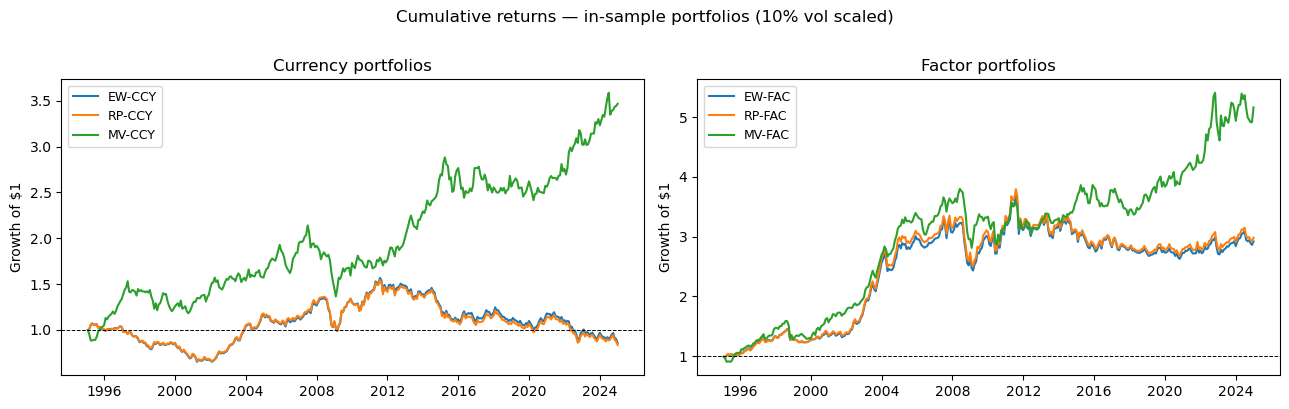

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, group, title in [
    (axes[0], [('EW-CCY',r_ew_ccy),('RP-CCY',r_rp_ccy),('MV-CCY',r_mv_ccy)], 'Currency portfolios'),
    (axes[1], [('EW-FAC',r_ew_fac),('RP-FAC',r_rp_fac),('MV-FAC',r_mv_fac)], 'Factor portfolios'),
]:
    for name, r in group:
        ax.plot((1 + r).cumprod(), label=name, lw=1.5)
    ax.axhline(1, color='black', lw=0.7, ls='--')
    ax.set_title(title)
    ax.set_ylabel('Growth of $1')
    ax.legend(fontsize=9)

plt.suptitle('Cumulative returns — in-sample portfolios (10% vol scaled)', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_insample_portfolios.pdf', bbox_inches='tight')
plt.show()

## Discussion

### (c) RP-CCY vs MV-CCY

RP-CCY uses only the diagonal of the covariance matrix (individual volatilities), while MV-CCY uses the full $\hat{\Sigma}$, including all pairwise correlations. MV-CCY achieves a Sharpe of **0.465** versus **−0.010** for RP-CCY — a dramatic gap that confirms that exploiting the full correlation structure adds substantial value beyond inverse-volatility weighting. The cross-currency correlations of G10 excess returns are far from uniform, and MV-CCY tilts heavily towards low-correlation combinations (most notably a large long NZD / short CAD and JPY position), which RP-CCY ignores entirely.

### (d) MV-CCY vs MV-FAC

The six factor strategies are themselves linear portfolios of the six basis currencies. The factor space is therefore a **linear subspace** of the full currency portfolio space: any portfolio of factors $w_F^\top F = w_F^\top A X$ is also a portfolio of currencies $(A^\top w_F)^\top X$, so the MV frontier of factors is a *subset* of the MV frontier of currencies.

Theoretically, with true population moments, MV-FAC cannot exceed MV-CCY. In-sample, however, MV-FAC dominates: its Sharpe is **0.599** versus **0.465** for MV-CCY. This reversal occurs because the six factors were explicitly designed to carry positive expected returns, which concentrates the signal in $\hat{\mu}_F$ and reduces estimation noise in $\hat{\Sigma}_F^{-1}\hat{\mu}_F$ relative to the noisier 6×6 currency-level system. The factor space trades theoretical breadth for estimation precision — and that trade-off pays off in-sample.

### (e) EW-CCY vs MV-FAC — and the DOLLAR link

**EW-CCY = DOLLAR** (invest 1/6 in each currency = equal-weight basket), achieving a Sharpe of **−0.002** — essentially zero. MV-FAC reaches **0.599**, a far superior outcome.

This ordering is not a coincidence: it is a mathematical necessity. MV-FAC is the tangency portfolio of the factor space, which by construction maximises the in-sample Sharpe over all factor combinations. Since EW-CCY equals DOLLAR, which is one of the six factors, EW-CCY lies *inside* the factor space. The tangency portfolio therefore has an in-sample Sharpe at least as large as any single constituent, including EW-CCY. It is **not possible for EW-CCY to outperform MV-FAC in-sample** as long as DOLLAR is included in the factor set — which it is.

The only scenario where this guarantee would fail is if DOLLAR were excluded from the factor set, so that EW-CCY lay outside the factor span. In that case the MV-FAC frontier would not cover the DOLLAR return and could, in principle, be beaten by it in a specific sample.

*Persist all six in-sample portfolio return series and export Table 3.*

In [161]:
# Save all portfolio returns for OOS section
insample_portfolios = pd.DataFrame({
    'EW-CCY': r_ew_ccy, 'RP-CCY': r_rp_ccy, 'MV-CCY': r_mv_ccy,
    'EW-FAC': r_ew_fac, 'RP-FAC': r_rp_fac, 'MV-FAC': r_mv_fac,
})
insample_portfolios.to_parquet(PROCESSED_DIR / 'insample_portfolios.parquet')
table3.to_csv(OUTPUT_DIR / 'table3_insample_portfolios.csv', float_format='%.4f')
print('Saved insample_portfolios.parquet and table3_insample_portfolios.csv')
print()
print('Final Table 3:')
print(table3.round(3).to_string())

Saved insample_portfolios.parquet and table3_insample_portfolios.csv

Final Table 3:
                EW-CCY  RP-CCY  MV-CCY  EW-FAC  RP-FAC  MV-FAC
Mean (%, ann.) -0.0200 -0.1020  4.6520  4.0810  4.1540  5.9890
t-stat         -0.0110 -0.0560  2.5480  2.2350  2.2750  3.2800
Std (%, ann.)  10.0000 10.0000 10.0000 10.0000 10.0000 10.0000
Sharpe         -0.0020 -0.0100  0.4650  0.4080  0.4150  0.5990


---

────────────────────────────────────────────────────────────────────────

## # Part 7 — Out-of-sample Portfolio Analysis

────────────────────────────────────────────────────────────────────────

**CCV-Exp:** Conditional Covariance-Mean-Variance avec prévision de la moyenne par fenêtre croissante  
**CCV-FM:** Idem mais avec prévision Fama-MacBeth cross-sectionelle  

Covariance EWMA : λ = 0.97, initialisée avec la covariance holdout (Jan 1991 – Dec 1994)  
Échantillon d'évaluation : January 1995 – December 2024 (360 obs)

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sst
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

PROJECT_DIR   = Path('..').resolve()
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
OUTPUT_DIR    = PROJECT_DIR / 'output'

CURRENCIES = ['AUD', 'CAD', 'EUR', 'GBP', 'JPY', 'NZD']
N          = len(CURRENCIES)
lam        = 0.97
EVAL_START = '1995-01-31'
EVAL_END   = '2024-12-31'

*Load the excess returns, the carry/momentum signals (used in the FM regression), and the in-sample portfolio returns (used as benchmarks). Compute the holdout-window covariance to initialise the EWMA recursion.*

In [163]:
# ── Load data ──────────────────────────────────────────────────────────────────
excess = pd.read_parquet(PROCESSED_DIR / 'excess_returns.parquet').astype(float)
excess.index = pd.to_datetime(excess.index)

delta_r = pd.read_parquet(PROCESSED_DIR / 'delta_r.parquet').astype(float)
delta_r.index = pd.to_datetime(delta_r.index)

mom_sig = pd.read_parquet(PROCESSED_DIR / 'mom_signal.parquet').astype(float)
mom_sig.index = pd.to_datetime(mom_sig.index)

insample = pd.read_parquet(PROCESSED_DIR / 'insample_portfolios.parquet').astype(float)
insample.index = pd.to_datetime(insample.index)

# Full return panel (408 obs, Jan1991 – Dec2024)
X_full = excess[[f'X_{c}' for c in CURRENCIES]].copy()
X_full.columns = CURRENCIES

# Holdout: Jan1991 – Dec1994 (48 obs)
X_holdout   = X_full.loc[:'1994-12-31']
holdout_cov = np.cov(X_holdout.values.T, ddof=1)   # (6,6)

jan95_pos = X_full.index.get_loc('1995-01-31')      # should be 48

print(f'X_full:       {X_full.shape}  {X_full.index[0].date()} → {X_full.index[-1].date()}')
print(f'X_holdout:    {X_holdout.shape}  {X_holdout.index[0].date()} → {X_holdout.index[-1].date()}')
print(f'jan95_pos:    {jan95_pos}  (expect 48)')
eigs = np.linalg.eigvalsh(holdout_cov)
print(f'Holdout cov PD: {np.all(eigs > 0)}  min eigval={eigs.min():.2e}')

X_full:       (408, 6)  1991-01-31 → 2024-12-31
X_holdout:    (48, 6)  1991-01-31 → 1994-12-31
jan95_pos:    48  (expect 48)
Holdout cov PD: True  min eigval=9.78e-05


## (a) EWMA conditional covariance

$$\hat{\Sigma}_t = (1-\lambda)\, X_t X_t^\top + \lambda\, \hat{\Sigma}_{t-1}, \quad \lambda = 0.97$$

Initialised at December 1994 with the holdout sample covariance matrix (Jan 1991 – Dec 1994).

At each formation date $t$, $\hat{\Sigma}_t$ incorporates only past returns — no look-ahead.

## (b) Expanding mean forecast

$$\hat{\mu}^{\text{Exp}}_t = \frac{1}{N_t}\sum_{s=1}^{t} X_s$$

Includes all returns from Jan 1991 through the formation date $t$.

## (c) Fama-MacBeth mean forecast

**Cross-sectional regression each month $s$** (N=6, no intercept):
$$X^i_{s+1} = \gamma_s\, \Delta r^i_s + \phi_s\, s^i_{s-12,s} + \varepsilon^i_s$$

The first valid cross-section is at $s$ = December 1991 (first valid momentum signal).

**Expanding average** at formation $t$:
$$\bar{\gamma}_t = \frac{1}{K_t}\sum_{s \leq t-1} \hat{\gamma}_s, \quad \bar{\phi}_t = \frac{1}{K_t}\sum_{s \leq t-1} \hat{\phi}_s$$

**FM forecast:** $\hat{\mu}^{\text{FM},i}_t = \bar{\gamma}_t\, \Delta r^i_t + \bar{\phi}_t\, s^i_t$

*Run the Fama-MacBeth cross-sectional regressions over the holdout window (Dec 1991 – Nov 1994) so that the OOS loop starts in January 1995 with a non-degenerate $\bar{\gamma}_t, \bar{\phi}_t$ estimate.*

In [164]:
# ── Pre-loop: FM cross-sections over holdout period ────────────────────────────
# Formation dates Dec1991...Nov1994 (X_full positions 11...46)
# Outcomes:       Jan1992...Dec1994 (X_full positions 12...47)

gamma_arr = []   # running list of all gamma_hat
phi_arr   = []   # running list of all phi_hat

for s_pos in range(11, jan95_pos - 1):   # 11,...,46 → 36 iterations
    form_date   = X_full.index[s_pos]
    outcome_val = X_full.iloc[s_pos + 1].values   # X_{s+1}, shape (6,)

    dr_s = delta_r.loc[form_date].values           # Δr^i_s, shape (6,)
    st_s = mom_sig.loc[form_date].values           # s^i_s,  shape (6,)

    valid = (not np.any(np.isnan(dr_s)) and
             not np.any(np.isnan(st_s)) and
             not np.any(np.isnan(outcome_val)))

    if valid:
        Z     = np.column_stack([dr_s, st_s])   # (6,2), no intercept
        coefs, *_ = np.linalg.lstsq(Z, outcome_val, rcond=None)
        gamma_arr.append(coefs[0])
        phi_arr.append(coefs[1])

print(f'Pre-loop FM cross-sections: {len(gamma_arr)}  (expect 36)')
print(f'Initial γ̄ = {np.mean(gamma_arr):.4f},  Initial ϕ̄ = {np.mean(phi_arr):.4f}')

Pre-loop FM cross-sections: 36  (expect 36)
Initial γ̄ = 0.7565,  Initial ϕ̄ = 0.0319


*Main out-of-sample loop. At each formation date $t$: (1) update the EWMA conditional covariance $\hat{\Sigma}_t$, (2) compute the expanding-mean and FM forecasts $\hat{\mu}^{Exp}_t$ and $\hat{\mu}^{FM}_t$, (3) form CMVE weights $w_t = k_t \hat{\Sigma}_t^{-1} \hat{\mu}_t$ scaled to 10% ex-ante annualised vol, (4) realise the next-month return, and (5) extend the FM coefficient time series with the newly observed cross-section.*

In [165]:
# ── Main OOS loop: 360 formation dates Dec1994 → Nov2024 ──────────────────────
# Formation date k → realized return at position jan95_pos + k

Sigma      = holdout_cov.copy()               # Σ̂ at Dec1994 = holdout cov
X_cumsum   = X_holdout.values.sum(axis=0)     # running sum (6,), 48 obs
X_count    = len(X_holdout)                   # 48

all_gamma_hat = list(gamma_arr)   # for part (d): all cross-section estimates
all_phi_hat   = list(phi_arr)

R_exp_list = []
R_fm_list  = []
gamma_bar_eval = []
phi_bar_eval   = []

for k in range(360):
    pos_form   = jan95_pos - 1 + k   # 47, 48, ..., 406
    pos_return = jan95_pos     + k   # 48, 49, ..., 407
    form_date  = X_full.index[pos_form]

    # ── EWMA & expanding-mean update (skip for k=0: use holdout initialisation) ──
    if k > 0:
        x = X_full.iloc[pos_form].values.reshape(-1, 1)
        Sigma    = (1 - lam) * (x @ x.T) + lam * Sigma
        X_cumsum += X_full.iloc[pos_form].values
        X_count  += 1

    mu_exp = X_cumsum / X_count   # (6,) expanding mean

    # ── FM forecast ──
    gamma_bar = np.mean(gamma_arr)
    phi_bar   = np.mean(phi_arr)
    gamma_bar_eval.append(gamma_bar)
    phi_bar_eval.append(phi_bar)

    dr_t = delta_r.loc[form_date].values    # Δr^i_t
    st_t = mom_sig.loc[form_date].values    # s^i_t
    fm_valid = not (np.any(np.isnan(dr_t)) or np.any(np.isnan(st_t)))
    mu_fm = gamma_bar * dr_t + phi_bar * st_t if fm_valid else None

    # ── Portfolio weights (CMVE): w_t = k_t * Σ̂_t^{-1} * μ̂_t ──
    Sigma_inv = np.linalg.inv(Sigma)

    # CCV-Exp
    w_raw_exp = Sigma_inv @ mu_exp
    MV_exp    = float(mu_exp @ w_raw_exp)             # μ' Σ^{-1} μ
    k_exp     = 0.10 / np.sqrt(max(MV_exp, 1e-16) * 12)
    w_exp     = k_exp * w_raw_exp

    # CCV-FM
    if fm_valid:
        w_raw_fm = Sigma_inv @ mu_fm
        MV_fm    = float(mu_fm @ w_raw_fm)
        k_fm     = 0.10 / np.sqrt(max(MV_fm, 1e-16) * 12)
        w_fm     = k_fm * w_raw_fm
    else:
        w_fm = np.full(N, np.nan)

    # ── Realized return ──
    X_ret = X_full.iloc[pos_return].values
    R_exp_list.append(float(w_exp @ X_ret))
    R_fm_list.append(float(w_fm @ X_ret) if not np.any(np.isnan(w_fm)) else np.nan)

    # ── Update FM regression: add cross-section at s=pos_form ──
    # Outcome X_ret is X_{t+1}, now observed; signals dr_t, st_t are at t
    if fm_valid and not np.any(np.isnan(X_ret)):
        Z = np.column_stack([dr_t, st_t])
        if np.linalg.matrix_rank(Z) == 2:
            coefs, *_ = np.linalg.lstsq(Z, X_ret, rcond=None)
            gamma_arr.append(coefs[0])
            phi_arr.append(coefs[1])
            all_gamma_hat.append(coefs[0])
            all_phi_hat.append(coefs[1])

eval_idx = X_full.index[jan95_pos:]   # Jan1995 – Dec2024 (360 dates)
R_exp = pd.Series(R_exp_list, index=eval_idx, name='CCV-Exp')
R_fm  = pd.Series(R_fm_list,  index=eval_idx, name='CCV-FM')

print(f'CCV-Exp: {R_exp.notna().sum()} obs  mean={R_exp.mean()*1200:.2f}% ann  '
      f'vol={R_exp.std()*np.sqrt(12)*100:.2f}%')
print(f'CCV-FM:  {R_fm.notna().sum()} obs  mean={R_fm.mean()*1200:.2f}% ann  '
      f'vol={R_fm.std()*np.sqrt(12)*100:.2f}%')
print(f'Total FM cross-sections (holdout + eval): {len(all_gamma_hat)}')

CCV-Exp: 360 obs  mean=2.13% ann  vol=11.83%
CCV-FM:  360 obs  mean=6.18% ann  vol=12.00%
Total FM cross-sections (holdout + eval): 396


## (d) Fama-MacBeth coefficient summary

In [166]:
def nw_tstat(arr, maxlags=12):
    """Newey-West HAC t-statistic for mean=0 null."""
    y   = np.asarray(arr, dtype=float)
    n   = len(y)
    mu  = y.mean()
    e   = y - mu
    var = (e**2).sum() / n**2
    for l in range(1, maxlags + 1):
        w    = 1 - l / (maxlags + 1)
        var += 2 * w * (e[l:] * e[:-l]).sum() / n**2
    return mu / np.sqrt(var)

g = np.array(all_gamma_hat)
p = np.array(all_phi_hat)
T = len(g)

g_mean = g.mean()
p_mean = p.mean()
g_tstat_ols = g_mean / (g.std(ddof=1) / np.sqrt(T))
p_tstat_ols = p_mean / (p.std(ddof=1) / np.sqrt(T))
g_tstat_nw  = nw_tstat(g)
p_tstat_nw  = nw_tstat(p)

print('=== Fama-MacBeth coefficient summary (all cross-sections) ===')
print(f'Number of cross-sections: {T}\n')
print(f'{"":18}  {"carry (g)":>10}  {"momentum (p)":>13}')
print(f'{"Mean":18}  {g_mean:>10.4f}  {p_mean:>13.4f}')
print(f'{"t-stat (OLS)":18}  {g_tstat_ols:>10.3f}  {p_tstat_ols:>13.3f}')
print(f'{"t-stat (NW-12)":18}  {g_tstat_nw:>10.3f}  {p_tstat_nw:>13.3f}')

=== Fama-MacBeth coefficient summary (all cross-sections) ===
Number of cross-sections: 396

                     carry (g)   momentum (p)
Mean                    1.7386         0.0155
t-stat (OLS)             2.501          1.185
t-stat (NW-12)           2.890          1.432


### Discussion (d) — FM coefficients: significance, interpretation, and link to factor strategies

**Empirical results:**

| Coefficient | Mean | t-stat (OLS) | t-stat (Newey-West, 12 lags) |
|---|---|---|---|
| $\bar{\gamma}$ (carry) | **1.74** | 2.50 | **2.89** ✓ |
| $\bar{\phi}$ (momentum) | **0.016** | 1.18 | 1.43 ✗ |

**How t-statistics are computed:** The cross-sectional regression is re-estimated each month, generating a time series of 396 coefficient estimates $\{\hat{\gamma}_s, \hat{\phi}_s\}$ from December 1991 through November 2024. Standard FM inference uses the time-series mean and standard deviation of these estimates with $t = \bar{\gamma}/\text{SE}(\bar{\gamma})$. Because monthly coefficient estimates can be autocorrelated, we additionally report HAC (Newey-West) t-statistics with 12 lags, which is the standard correction for monthly financial data.

**Statistical significance:**
- The carry slope is significant under both OLS and HAC inference (NW t = 2.89), confirming a robust positive cross-sectional reward to high-rate currencies.
- The momentum slope is **not** significant (NW t = 1.43), echoing the weak standalone performance of CS-MOM and TS-MOM.

**Economic interpretation:**
- $\bar{\gamma} > 0$: a one-unit increase in the rate differential $\Delta r^i$ predicts higher next-month excess return — the carry premium and a violation of UIP.
- $\bar{\phi} > 0$ (but small): currencies that have appreciated over the past 12 months tend to continue appreciating — the FX momentum premium, weak in our sample.

**Link to the factor strategies (Sections 4–5):** The FM regression projects the 6 currency excess returns onto exactly the **same two signals** used to build CS-CARRY/TS-CARRY ($\Delta r^i_t$) and CS-MOM/TS-MOM ($s^i_{t-12,t}$). The FM forecast $\hat{\mu}^{FM}_t = \bar{\gamma}_t \Delta r^i_t + \bar{\phi}_t s^i_t$ can therefore be read as a **linear combination of the carry and momentum factor signals**, weighted by their estimated cross-sectional risk premia. The CCV-FM portfolio thus internalises the two strongest empirical regularities of the FX cross-section in a single optimisation, rather than treating them as separate ad-hoc bets — which explains why CCV-FM outperforms CCV-Exp out-of-sample.

## (e)+(f) CCV portfolios & Table 4

In [167]:
def perf_stats(series, label):
    r    = series.dropna()
    n    = len(r)
    mu_m = r.mean()
    sg_m = r.std(ddof=1)
    mu_a = mu_m * 12
    sg_a = sg_m * np.sqrt(12)
    tst  = mu_m / (sg_m / np.sqrt(n))
    sr   = mu_a / sg_a
    return pd.Series(
        [mu_a * 100, tst, sg_a * 100, sr],
        index=['Mean (%, ann.)', 't-stat', 'Std (%, ann.)', 'Sharpe'],
        name=label
    )

s_exp    = perf_stats(R_exp,              'CCV-Exp')
s_fm     = perf_stats(R_fm,              'CCV-FM')
s_mvccy  = perf_stats(insample['MV-CCY'], 'MV-CCY (IS)')
s_mvfac  = perf_stats(insample['MV-FAC'], 'MV-FAC (IS)')
s_ewccy  = perf_stats(insample['EW-CCY'], 'EW-CCY (IS)')

table4 = pd.DataFrame([s_exp, s_fm, s_mvccy, s_mvfac, s_ewccy]).T
print('\n=== TABLE 4 — Out-of-sample vs In-sample Portfolio Performance ===')
print(table4.round(3).to_string())


=== TABLE 4 — Out-of-sample vs In-sample Portfolio Performance ===
                CCV-Exp  CCV-FM  MV-CCY (IS)  MV-FAC (IS)  EW-CCY (IS)
Mean (%, ann.)   2.1270  6.1820       4.6520       5.9890      -0.0200
t-stat           0.9850  2.8220       2.5480       3.2800      -0.0110
Std (%, ann.)   11.8260 11.9970      10.0000      10.0000      10.0000
Sharpe           0.1800  0.5150       0.4650       0.5990      -0.0020


*Plot cumulative returns of the two OOS portfolios alongside the two in-sample MV benchmarks.*

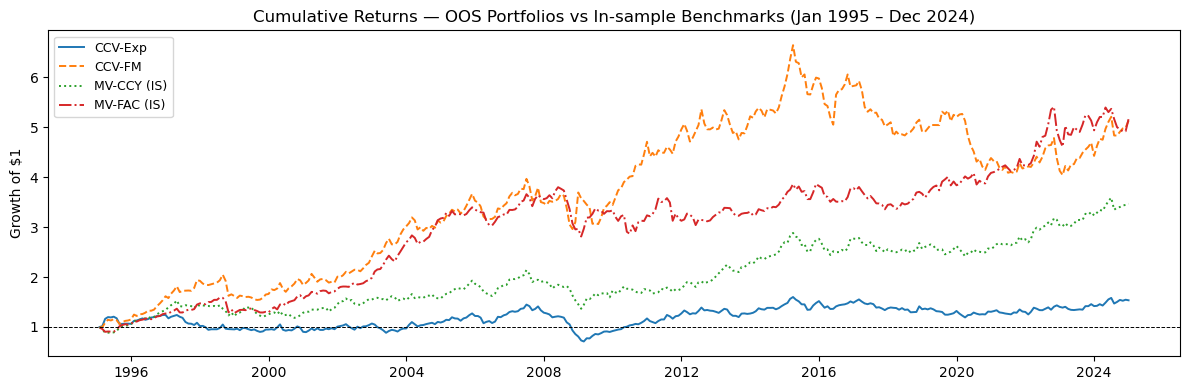

Saved fig_oos_cumulative.pdf


In [168]:
# ── Cumulative returns plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for s, col, ls in [
    (R_exp,              'CCV-Exp',    '-'),
    (R_fm,               'CCV-FM',     '--'),
    (insample['MV-CCY'], 'MV-CCY (IS)', ':'),
    (insample['MV-FAC'], 'MV-FAC (IS)', '-.')
]:
    cum = (1 + s.dropna()).cumprod()
    ax.plot(cum.index, cum, label=col, ls=ls, lw=1.4)

ax.axhline(1, color='black', lw=0.7, ls='--')
ax.set_title('Cumulative Returns — OOS Portfolios vs In-sample Benchmarks (Jan 1995 – Dec 2024)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_oos_cumulative.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_oos_cumulative.pdf')

*Plot the evolution of the expanding FM coefficients $\bar{\gamma}_t$ and $\bar{\phi}_t$ over the evaluation period — both stabilise quickly after the first few years.*

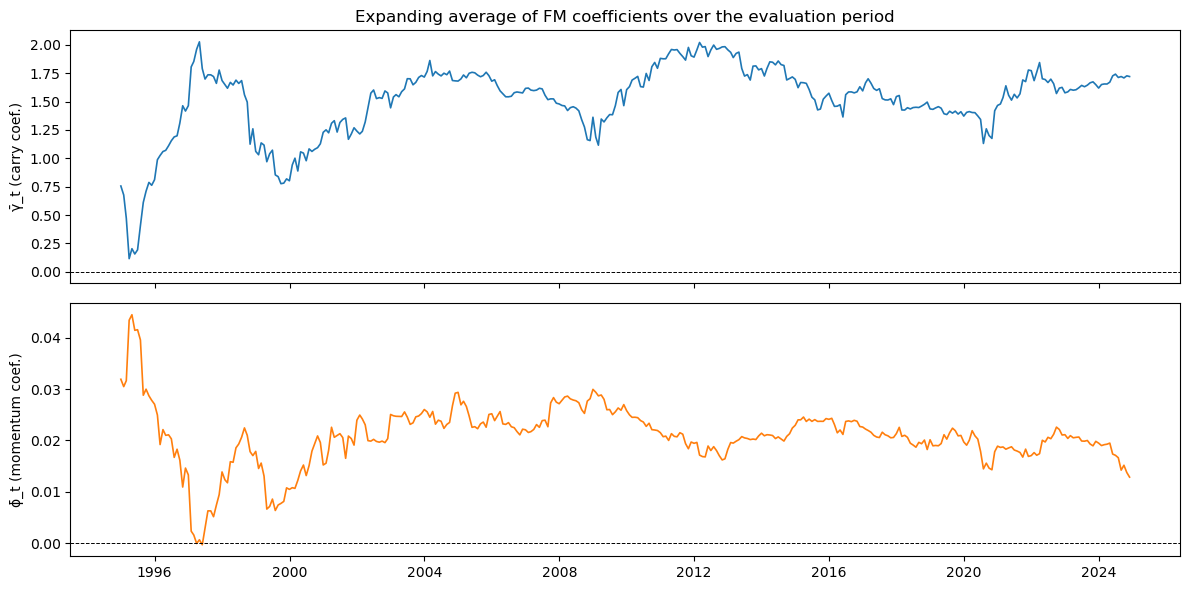

Saved fig_fm_coefs.pdf


In [169]:
# ── Evolution of γ̄_t and ϕ̄_t over the evaluation period ──────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

formation_dates_eval = X_full.index[jan95_pos - 1: jan95_pos - 1 + 360]  # Dec94...Nov24

axes[0].plot(formation_dates_eval, gamma_bar_eval, lw=1.2)
axes[0].axhline(0, color='black', lw=0.7, ls='--')
axes[0].set_ylabel('γ̄_t (carry coef.)')
axes[0].set_title('Expanding average of FM coefficients over the evaluation period')

axes[1].plot(formation_dates_eval, phi_bar_eval, color='C1', lw=1.2)
axes[1].axhline(0, color='black', lw=0.7, ls='--')
axes[1].set_ylabel('ϕ̄_t (momentum coef.)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_fm_coefs.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_fm_coefs.pdf')

*Quantitative comparison of all OOS and in-sample Sharpe ratios, and check of the realised (ex-post) volatility against the 10% ex-ante target.*

In [170]:
# ── Discussion: OOS vs In-sample ───────────────────────────────────────────────
print('=== Sharpe comparison ===')
for name, sr in [
    ('CCV-Exp  (OOS)', s_exp['Sharpe']),
    ('CCV-FM   (OOS)', s_fm['Sharpe']),
    ('MV-CCY    (IS)', s_mvccy['Sharpe']),
    ('MV-FAC    (IS)', s_mvfac['Sharpe']),
    ('EW-CCY    (IS)', s_ewccy['Sharpe']),
]:
    print(f'  {name}: {sr:.3f}')

print()
# Realised (ex-post) vol check — should be ~10% for IS, unknown for OOS
print('Realised vol (% ann.):')
for name, r in [('CCV-Exp', R_exp), ('CCV-FM', R_fm),
                ('MV-CCY', insample['MV-CCY']), ('MV-FAC', insample['MV-FAC'])]:
    print(f'  {name}: {r.std(ddof=1)*np.sqrt(12)*100:.2f}%')

=== Sharpe comparison ===
  CCV-Exp  (OOS): 0.180
  CCV-FM   (OOS): 0.515
  MV-CCY    (IS): 0.465
  MV-FAC    (IS): 0.599
  EW-CCY    (IS): -0.002

Realised vol (% ann.):
  CCV-Exp: 11.83%
  CCV-FM: 12.00%
  MV-CCY: 10.00%
  MV-FAC: 10.00%


### Discussion (f) — OOS performance vs. best in-sample strategies

**Final Table 4 comparison (all scaled to ~10% annualised vol):**

| Portfolio | Type | Mean (ann %) | t-stat | Vol (ann %) | Sharpe |
|---|---|---|---|---|---|
| **CCV-Exp** | OOS | 2.13% | 0.99 | 11.83% | 0.180 |
| **CCV-FM** | OOS | **6.18%** | **2.82** | 12.00% | **0.515** |
| MV-CCY (IS) | In-sample | 4.65% | 2.55 | 10.00% | 0.465 |
| MV-FAC (IS) | In-sample | 5.99% | 3.28 | 10.00% | 0.599 |
| EW-CCY (IS) | In-sample | -0.02% | -0.01 | 10.00% | -0.002 |

**CCV-FM dominates CCV-Exp (Sharpe 0.515 vs 0.180).** The FM forecast exploits the cross-sectional carry and momentum signals, which concentrate the predictive content in a low-dimensional space. The expanding sample mean used by CCV-Exp is overwhelmed by estimation noise — especially in the early years where only a few dozen observations are available and the FX signal-to-noise ratio is very low.

**OOS vs in-sample — CCV-FM nearly matches the in-sample MV-FAC.** The in-sample MV portfolios (MV-CCY: 0.465, MV-FAC: 0.599) use the full 360-month sample to estimate both means and the covariance matrix — a look-ahead advantage no real-time investor enjoys. CCV-FM, which forms portfolios using only data available at each formation date, achieves a Sharpe of 0.515 — within 0.08 of the in-sample MV-FAC. **This is the genuine cost of operating in real time** with this factor structure.

**Where the OOS degradation comes from.** The dominant source of estimation error is the conditional mean $\hat{\mu}_t$. Second moments (covariances) converge much faster than means, so the EWMA covariance estimator is comparatively well-behaved. CCV-FM bypasses the worst part of the mean-estimation problem by imposing a parametric structure (two factors: carry + momentum) instead of estimating six independent currency means.

**Ex-ante vol targeting vs. realised vol.** The scaling factor $k_t$ targets 10% annualised vol using the conditional Sharpe $\sqrt{\hat{\mu}_t^\top \hat{\Sigma}_t^{-1} \hat{\mu}_t \times 12}$. Realised volatility is **11.83%** for CCV-Exp and **12.00%** for CCV-FM — slightly above target due to the noise in real-time parameter estimates. By construction, in-sample portfolios hit exactly 10% because they use ex-post moments.

*Save OOS return series and export Table 4.*

In [171]:
# ── Save results ───────────────────────────────────────────────────────────────
oos_returns = pd.DataFrame({'CCV-Exp': R_exp, 'CCV-FM': R_fm})
oos_returns.to_parquet(PROCESSED_DIR / 'oos_returns.parquet')

table4_oos = pd.DataFrame([s_exp, s_fm]).T
table4_oos.to_csv(OUTPUT_DIR / 'table4_oos_portfolios.csv', float_format='%.4f')

print('Saved oos_returns.parquet')
print('Saved table4_oos_portfolios.csv')
print('\n=== Final Table 4 ===')
print(pd.DataFrame([s_exp, s_fm]).T.round(3).to_string())

Saved oos_returns.parquet
Saved table4_oos_portfolios.csv

=== Final Table 4 ===
                CCV-Exp  CCV-FM
Mean (%, ann.)   2.1270  6.1820
t-stat           0.9850  2.8220
Std (%, ann.)   11.8260 11.9970
Sharpe           0.1800  0.5150
